# Tarefa 3 - Modelos com PyTorch + Redes Recorrentes + Embeddings

| Modelo | Como le o texto | Nota |
|---|---|---|
| **FFNN-BOW** | Bag-of-Words esparso | Baseline classico |
| **FFNN-TF-IDF** | TF-IDF + bigramas | Melhor baseline tabular |
| **Vanilla RNN** | -> esq. para dir. | Mais simples; vanishing gradient |
| **LSTM** | -> esq. para dir. | Gates resolvem o vanishing gradient |
| **BiLSTM** | -> + <- ambas as direccoes | Contexto futuro e passado |
| **GRU** | -> esq. para dir. | LSTM simplificado, menos parametros |
| **EmbeddingMLP** | mean-pool de embeddings treinaveis | Sem recorrencia; embeddings end-to-end |
| **BiLSTM-GloVe** | BiLSTM + GloVe congelado | Transfer learning de embeddings |

In [1]:
import re, time, pickle, warnings
from collections import Counter
import scipy.sparse as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score as sk_f1

warnings.filterwarnings('ignore')

# ── CONFIG ──────────────────────────────────────────────────────────────────────
SEED           = 808815

MAX_WORDS_FFNN = 10_000   # BOW/TF-IDF: vocab menor = muito mais rápido
MAX_WORDS_RNN  = 20_000   # RNNs aguentam vocab maior
MAX_LEN        = 180

BATCH_SIZE = 512    # batch maior = menos iterações por época
EPOCHS     = 10
LR         = 1e-3
PATIENCE   = 5

# Hiperparâmetros fixos por modelo (sem Optuna)
HP = {
    'FFNN-BOW':    dict(hidden_dims=(512, 256, 128), dropout=0.3,  lr=3e-4),
    'FFNN-TF-IDF': dict(hidden_dims=(512, 256, 128), dropout=0.3,  lr=3e-4),
    'RNN':         dict(embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.3, lr=1e-3),
    'LSTM':        dict(embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.3, lr=1e-3),
    'BiLSTM':      dict(embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.3, lr=1e-3),
    'GRU':         dict(embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.3, lr=1e-3),
    'EmbeddingMLP':dict(embed_dim=128, hidden_dim=256, dropout=0.3,              lr=1e-3),
    'BiLSTM-GloVe':dict(hidden_dim=256, num_layers=1, dropout=0.3,              lr=5e-4),
}

EMBED_DIM  = 128
HIDDEN_DIM = 256

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print(f'Device: {DEVICE}')
print(f'MAX_LEN={MAX_LEN}  EMBED_DIM={EMBED_DIM}  HIDDEN_DIM={HIDDEN_DIM}')
print(f'MAX_WORDS_FFNN={MAX_WORDS_FFNN}  MAX_WORDS_RNN={MAX_WORDS_RNN}  BATCH_SIZE={BATCH_SIZE}')


Device: cuda
MAX_LEN=180  EMBED_DIM=128  HIDDEN_DIM=256
MAX_WORDS_FFNN=10000  MAX_WORDS_RNN=20000  BATCH_SIZE=512


## 1. Carregamento e Pré-processamento

Split estratificado **70 / 15 / 15** — igual ao notebook NumPy.

In [2]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    return re.sub(r'\s+', ' ', text).strip()

# ── Carregar ──────────────────────────────────────────────────────────────────
df = load_dataset("BrunoFilipeRDS/50k-balanced-5-classes", split='train').to_pandas()
df = df.dropna(subset=['text', 'label']).copy()
df['text']  = df['text'].astype(str).apply(clean_text)
df['label'] = df['label'].astype(str)

CLASSES      = sorted(df['label'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
N_CLASSES    = len(CLASSES)
df['label_id'] = df['label'].map(CLASS_TO_IDX)

texts  = df['text'].tolist()
labels = df['label_id'].tolist()

print(f'Dataset: {len(df)} linhas | {N_CLASSES} classes')
print(df['label'].value_counts())

# ── Split estratificado ───────────────────────────────────────────────────────
X_tv, X_test, y_tv, y_test = train_test_split(
    texts, labels, test_size=0.15, stratify=labels, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=round(0.15/0.85, 4), stratify=y_tv, random_state=SEED)

print(f'\nTrain: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Dataset: 250000 linhas | 5 classes
label
Openai       50000
Google       50000
Meta         50000
Anthropic    50000
Human        50000
Name: count, dtype: int64

Train: 174993  |  Val: 37507  |  Test: 37500


### Análise do Comprimento dos Textos
Confirmar que `MAX_LEN=180` cobre bem a distribuição real dos dados de treino.

Comprimento dos textos de treino (palavras):
  p 50: 116
  p 75: 134
  p 90: 147
  p 95: 151
  p 99: 169
  p100: 2030


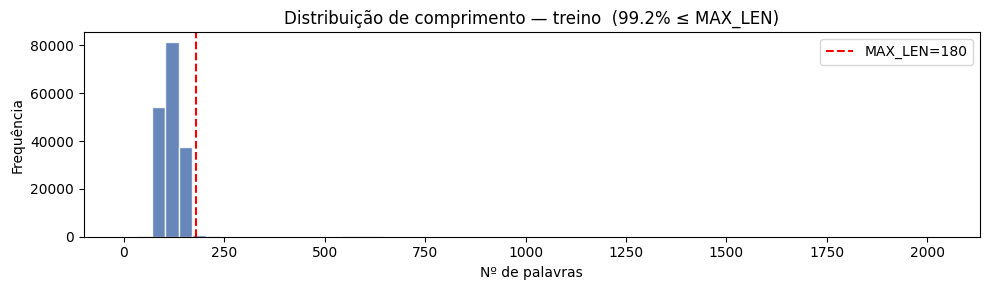

In [3]:
# ── Distribuição de comprimento (em palavras) ─────────────────────────────────
lens_train = [len(t.split()) for t in X_train]
pcts = np.percentile(lens_train, [50, 75, 90, 95, 99, 100])
print('Comprimento dos textos de treino (palavras):')
for p, v in zip([50, 75, 90, 95, 99, 100], pcts):
    print(f'  p{p:3d}: {v:.0f}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(lens_train, bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(MAX_LEN, color='red', linestyle='--', lw=1.5, label=f'MAX_LEN={MAX_LEN}')
covered = sum(l <= MAX_LEN for l in lens_train) / len(lens_train) * 100
ax.set(xlabel='Nº de palavras', ylabel='Frequência',
       title=f'Distribuição de comprimento — treino  ({covered:.1f}% ≤ MAX_LEN)')
ax.legend(); plt.tight_layout(); plt.show()

### 1.1 Comparação de Representações

| Representação | Usada por | Descrição |
|---|---|---|
| **BOW** | FFNN-1 | Vetor binário (palavra presente/ausente) |
| **TF-IDF** | FFNN-2 | Frequência pesada por raridade da palavra |
| **Sequências** | Todos os RNNs | IDs de tokens com padding |

In [4]:
# ── Vocabulário ────────────────────────────────────────────────────────────────
def build_vocab(texts, max_words=10_000):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for i, (w, _) in enumerate(counter.most_common(max_words - 2), start=2):
        vocab[w] = i
    return vocab

vocab_bow = build_vocab(X_train, max_words=MAX_WORDS_FFNN)
vocab_rnn = build_vocab(X_train, max_words=MAX_WORDS_RNN)
VOCAB_SIZE_FFNN = len(vocab_bow)
VOCAB_SIZE_RNN  = len(vocab_rnn)
print(f'Vocab FFNN (BOW/TF-IDF): {VOCAB_SIZE_FFNN}')
print(f'Vocab RNN  (embeddings): {VOCAB_SIZE_RNN}')

# ── BOWDataset — pré-computa matriz esparsa UMA vez, serve por batch ─────────
# (versão antiga reconstruia o vetor a cada __getitem__ — 85min/época!)
class BOWDataset(Dataset):
    def __init__(self, texts, labels, word_index, vocab_size):
        self.labels     = torch.tensor(labels, dtype=torch.long)
        self.vocab_size = vocab_size
        print(f'  A pré-computar BOW ({len(texts)} textos)...', end=' ', flush=True)
        t0 = time.time()
        rows, cols = [], []
        for i, text in enumerate(texts):
            for w in set(text.split()):
                idx = word_index.get(w, 1)
                if idx < vocab_size:
                    rows.append(i)
                    cols.append(idx)
        self.X = sp.csr_matrix(
            ([1.0] * len(rows), (rows, cols)),
            shape=(len(texts), vocab_size), dtype=np.float32)
        print(f'pronto em {time.time()-t0:.1f}s')

    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx):
        row = torch.tensor(self.X[idx].toarray(), dtype=torch.float32).squeeze(0)
        return row, self.labels[idx]

bow_train_loader = DataLoader(BOWDataset(X_train, y_train, vocab_bow, VOCAB_SIZE_FFNN), BATCH_SIZE, shuffle=True)
bow_val_loader   = DataLoader(BOWDataset(X_val,   y_val,   vocab_bow, VOCAB_SIZE_FFNN), BATCH_SIZE)
bow_test_loader  = DataLoader(BOWDataset(X_test,  y_test,  vocab_bow, VOCAB_SIZE_FFNN), BATCH_SIZE)
print('BOW DataLoaders prontos')


Vocab FFNN (BOW/TF-IDF): 10000
Vocab RNN  (embeddings): 20000
  A pré-computar BOW (174993 textos)... pronto em 12.3s
  A pré-computar BOW (37507 textos)... pronto em 2.9s
  A pré-computar BOW (37500 textos)... pronto em 3.1s
BOW DataLoaders prontos


In [5]:
# ── TF-IDF com bigramas (fit só no treino) ────────────────────────────────────
print('A ajustar TF-IDF (unigramas + bigramas)...')
t0 = time.time()

tfidf_vec = TfidfVectorizer(
    max_features = MAX_WORDS_FFNN,
    sublinear_tf = True,
    min_df       = 10,
    ngram_range  = (1, 2)
)

# Manter ESPARSO — .toarray() só por batch no SparseDataset (evita OOM)
X_tf_tr_sp   = tfidf_vec.fit_transform(X_train)
X_tf_val_sp  = tfidf_vec.transform(X_val)
X_tf_test_sp = tfidf_vec.transform(X_test)
print(f'TF-IDF {X_tf_tr_sp.shape}  ({time.time()-t0:.1f}s)')
print(f'Memória esparsa: {X_tf_tr_sp.nnz * 4 / 1e9:.3f} GB  '
      f'(vs {X_tf_tr_sp.shape[0] * X_tf_tr_sp.shape[1] * 4 / 1e9:.1f} GB denso)')

y_tr_t  = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val,   dtype=torch.long)
y_te_t  = torch.tensor(y_test,  dtype=torch.long)

class SparseDataset(Dataset):
    """Converte linha esparsa para tensor denso só quando o DataLoader pede."""
    def __init__(self, X_sparse, y_tensor):
        self.X = X_sparse
        self.y = y_tensor
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx):
        row = torch.tensor(self.X[idx].toarray(), dtype=torch.float32).squeeze(0)
        return row, self.y[idx]

tfidf_train_loader = DataLoader(SparseDataset(X_tf_tr_sp,   y_tr_t),  BATCH_SIZE, shuffle=True)
tfidf_val_loader   = DataLoader(SparseDataset(X_tf_val_sp,  y_val_t), BATCH_SIZE)
tfidf_test_loader  = DataLoader(SparseDataset(X_tf_test_sp, y_te_t),  BATCH_SIZE)
print('TF-IDF DataLoaders prontos')


A ajustar TF-IDF (unigramas + bigramas)...
TF-IDF (174993, 10000)  (95.0s)
Memória esparsa: 0.054 GB  (vs 7.0 GB denso)
TF-IDF DataLoaders prontos


In [6]:
# ── Sequências para RNNs — pré-computadas ────────────────────────────────────
class SequenceDataset(Dataset):
    def __init__(self, texts, labels, word_index, max_len):
        print(f'  A pré-computar sequências ({len(texts)} textos)...', end=' ', flush=True)
        t0 = time.time()
        self.labels = torch.tensor(labels, dtype=torch.long)
        data = np.zeros((len(texts), max_len), dtype=np.int64)
        for i, text in enumerate(texts):
            toks = text.split()[:max_len]
            for j, tok in enumerate(toks):
                data[i, j] = word_index.get(tok, 1)
        self.X = torch.tensor(data, dtype=torch.long)
        print(f'pronto em {time.time()-t0:.1f}s')

    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.labels[idx]

seq_train_loader = DataLoader(SequenceDataset(X_train, y_train, vocab_rnn, MAX_LEN), BATCH_SIZE, shuffle=True)
seq_val_loader   = DataLoader(SequenceDataset(X_val,   y_val,   vocab_rnn, MAX_LEN), BATCH_SIZE)
seq_test_loader  = DataLoader(SequenceDataset(X_test,  y_test,  vocab_rnn, MAX_LEN), BATCH_SIZE)
print('Sequência DataLoaders prontos')

  A pré-computar sequências (174993 textos)... pronto em 9.6s
  A pré-computar sequências (37507 textos)... pronto em 2.0s
  A pré-computar sequências (37500 textos)... pronto em 2.0s
Sequência DataLoaders prontos


## 2. Infraestrutura de Treino

In [7]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x)
            total_loss += criterion(out, y).item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total


def train_model(model, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, patience=PATIENCE, label=''):
    """
    AdamW + CrossEntropyLoss + Early Stopping + Gradient Clipping
    + ReduceLROnPlateau. Restaura os melhores pesos no final.
    """
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=False)

    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val  = float('inf')
    best_state, no_improve = None, 0
    t0 = time.time()

    for ep in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        tr_l, tr_a = evaluate(model, train_loader, criterion)
        vl_l, vl_a = evaluate(model, val_loader,   criterion)
        for k, v in zip(['train_loss','val_loss','train_acc','val_acc'],
                        [tr_l, vl_l, tr_a, vl_a]):
            history[k].append(v)

        scheduler.step(vl_l)
        elapsed = time.time() - t0
        print(f'[{label}] Época {ep:3d}/{epochs}  loss={tr_l:.4f}  acc={tr_a:.4f}  '
              f'val_loss={vl_l:.4f}  val_acc={vl_a:.4f}  '
              f'lr={optimizer.param_groups[0]["lr"]:.2e}  ({elapsed:.0f}s)')

        if vl_l < best_val:
            best_val   = vl_l
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  ↳ Early stopping época {ep}. Melhor val_loss={best_val:.4f}')
                break

    if best_state:
        model.load_state_dict(best_state)
        model.to(DEVICE)
    return history


def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    eps = range(1, len(history['train_loss']) + 1)
    ax1.plot(eps, history['train_loss'], label='Train')
    ax1.plot(eps, history['val_loss'],   label='Val')
    ax1.set(xlabel='Época', ylabel='Loss',     title=f'Loss — {title}'); ax1.legend()
    ax2.plot(eps, history['train_acc'],  label='Train')
    ax2.plot(eps, history['val_acc'],    label='Val')
    ax2.set(xlabel='Época', ylabel='Accuracy', title=f'Accuracy — {title}'); ax2.legend()
    plt.tight_layout(); plt.show()


def plot_confusion(model, loader, title='Matriz de Confusão'):
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for x, y in loader:
            all_p.extend(model(x.to(DEVICE)).argmax(1).cpu().tolist())
            all_t.extend(y.tolist())
    lbls = [IDX_TO_CLASS[i] for i in range(N_CLASSES)]
    cm   = confusion_matrix(all_t, all_p)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=lbls).plot(
        ax=ax, xticks_rotation=45, cmap='Blues', values_format='d')
    ax.set_title(title); plt.tight_layout(); plt.show()
    print(classification_report(all_t, all_p, target_names=lbls, digits=4))

print('Infraestrutura de treino pronta  (grad clipping + ReduceLROnPlateau + early stopping)')

Infraestrutura de treino pronta  (grad clipping + ReduceLROnPlateau + early stopping)


## 3. Baseline: FFNN

Feed-Forward Neural Network com BOW e TF-IDF.

In [8]:
class FFNNClassifier(nn.Module):
    """
    Feed-Forward Neural Network para classificação.
    Usa BatchNorm1d antes de cada activação para estabilizar
    os inputs de alta dimensão (30k features TF-IDF / BOW).
    """
    def __init__(self, input_dim, num_classes, hidden_dims=(512, 256, 128), dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

print('FFNNClassifier definido  (Linear → BatchNorm → ReLU → Dropout)')

FFNNClassifier definido  (Linear → BatchNorm → ReLU → Dropout)


FFNN-BOW
[FFNN-BOW] Época   1/10  loss=0.2447  acc=0.9202  val_loss=0.3760  val_acc=0.8604  lr=3.00e-04  (50s)
[FFNN-BOW] Época   2/10  loss=0.1337  acc=0.9607  val_loss=0.3579  val_acc=0.8709  lr=3.00e-04  (101s)
[FFNN-BOW] Época   3/10  loss=0.0684  acc=0.9814  val_loss=0.3879  val_acc=0.8704  lr=3.00e-04  (150s)
[FFNN-BOW] Época   4/10  loss=0.0380  acc=0.9897  val_loss=0.4261  val_acc=0.8716  lr=3.00e-04  (205s)
[FFNN-BOW] Época   5/10  loss=0.0241  acc=0.9932  val_loss=0.4676  val_acc=0.8702  lr=3.00e-04  (254s)
[FFNN-BOW] Época   6/10  loss=0.0163  acc=0.9958  val_loss=0.4858  val_acc=0.8720  lr=1.50e-04  (304s)
[FFNN-BOW] Época   7/10  loss=0.0072  acc=0.9981  val_loss=0.5065  val_acc=0.8758  lr=1.50e-04  (354s)
  ↳ Early stopping época 7. Melhor val_loss=0.3579


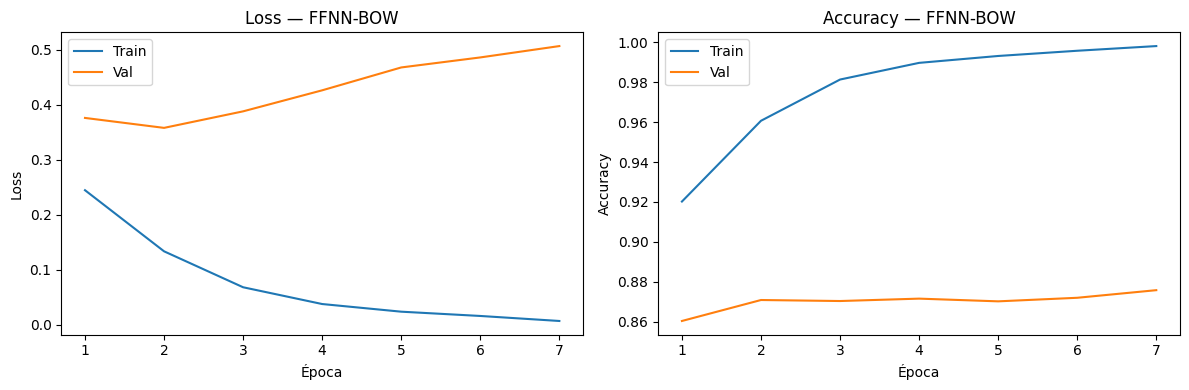

In [32]:
# ── FFNN-BOW ──────────────────────────────────────────────────────────────────
print('=' * 60)
print('FFNN-BOW')
print('=' * 60)
hp = HP['FFNN-BOW']
ffnn_bow = FFNNClassifier(VOCAB_SIZE_FFNN, N_CLASSES,
                          hidden_dims=hp['hidden_dims'], dropout=hp['dropout'])
hist_bow = train_model(ffnn_bow, bow_train_loader, bow_val_loader,
                       epochs=EPOCHS, lr=hp['lr'], patience=PATIENCE, label='FFNN-BOW')
plot_history(hist_bow, 'FFNN-BOW')

FFNN-TF-IDF
[FFNN-TF-IDF] Época   1/10  loss=0.2179  acc=0.9293  val_loss=0.3594  val_acc=0.8687  lr=3.00e-04  (52s)
[FFNN-TF-IDF] Época   2/10  loss=0.1123  acc=0.9690  val_loss=0.3480  val_acc=0.8752  lr=3.00e-04  (105s)
[FFNN-TF-IDF] Época   3/10  loss=0.0534  acc=0.9861  val_loss=0.3769  val_acc=0.8772  lr=3.00e-04  (159s)
[FFNN-TF-IDF] Época   4/10  loss=0.0276  acc=0.9931  val_loss=0.4240  val_acc=0.8779  lr=3.00e-04  (212s)
[FFNN-TF-IDF] Época   5/10  loss=0.0166  acc=0.9960  val_loss=0.4422  val_acc=0.8800  lr=3.00e-04  (268s)
[FFNN-TF-IDF] Época   6/10  loss=0.0119  acc=0.9972  val_loss=0.4738  val_acc=0.8787  lr=1.50e-04  (326s)
[FFNN-TF-IDF] Época   7/10  loss=0.0049  acc=0.9991  val_loss=0.4863  val_acc=0.8824  lr=1.50e-04  (376s)
  ↳ Early stopping época 7. Melhor val_loss=0.3480


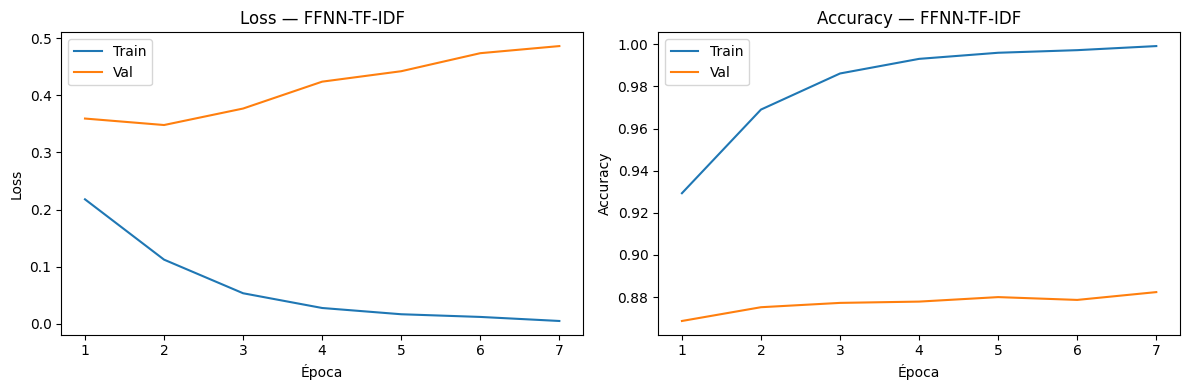

In [33]:
# ── FFNN-TF-IDF ───────────────────────────────────────────────────────────────
print('=' * 60)
print('FFNN-TF-IDF')
print('=' * 60)
hp = HP['FFNN-TF-IDF']
ffnn_tfidf = FFNNClassifier(MAX_WORDS_FFNN, N_CLASSES,
                             hidden_dims=hp['hidden_dims'], dropout=hp['dropout'])
hist_tfidf = train_model(ffnn_tfidf, tfidf_train_loader, tfidf_val_loader,
                         epochs=EPOCHS, lr=hp['lr'], patience=PATIENCE, label='FFNN-TF-IDF')
plot_history(hist_tfidf, 'FFNN-TF-IDF')

## 4. Redes Recorrentes

Todos os modelos partilham a arquitectura: `Embedding → RNN → Dropout → Linear`

In [9]:
class RecurrentClassifier(nn.Module):
    """
    Classificador recorrente genérico.
    rnn_type      : 'RNN' | 'LSTM' | 'GRU'
    pretrained_emb: np.ndarray (vocab_size, embed_dim) ou None
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 rnn_type='LSTM', num_layers=1, dropout=0.3, bidirectional=False,
                 pretrained_emb=None):
        super().__init__()
        self.rnn_type      = rnn_type
        self.bidirectional = bidirectional

        if pretrained_emb is not None:
            emb_tensor = torch.tensor(pretrained_emb, dtype=torch.float32)
            self.embedding = nn.Embedding.from_pretrained(
                emb_tensor, freeze=False, padding_idx=0)  # fine-tune com 50k/classe
            embed_dim = emb_tensor.shape[1]
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = bidirectional,
            dropout       = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        direction    = 2 if bidirectional else 1
        self.fc      = nn.Linear(hidden_dim * direction, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        if self.rnn_type == 'LSTM':
            _, (h, _) = self.rnn(emb)
        else:
            _, h = self.rnn(emb)
        h_last = torch.cat((h[-2], h[-1]), dim=1) if self.bidirectional else h[-1]
        return self.fc(self.dropout(h_last))

print('RecurrentClassifier definido.')

RecurrentClassifier definido.


Vanilla RNN
[RNN] Época   1/10  loss=1.6022  acc=0.2057  val_loss=1.6038  val_acc=0.2047  lr=1.00e-03  (20s)
[RNN] Época   2/10  loss=1.6440  acc=0.2064  val_loss=1.6460  val_acc=0.2053  lr=1.00e-03  (39s)
[RNN] Época   3/10  loss=1.5993  acc=0.2201  val_loss=1.6020  val_acc=0.2191  lr=1.00e-03  (57s)
[RNN] Época   4/10  loss=1.5988  acc=0.2018  val_loss=1.6022  val_acc=0.1999  lr=1.00e-03  (74s)
[RNN] Época   5/10  loss=1.5998  acc=0.2057  val_loss=1.6031  val_acc=0.2044  lr=1.00e-03  (90s)
[RNN] Época   6/10  loss=1.5989  acc=0.2066  val_loss=1.6029  val_acc=0.2048  lr=1.00e-03  (106s)
[RNN] Época   7/10  loss=1.5987  acc=0.2071  val_loss=1.6026  val_acc=0.2052  lr=5.00e-04  (122s)
[RNN] Época   8/10  loss=1.5974  acc=0.2072  val_loss=1.6022  val_acc=0.2051  lr=5.00e-04  (138s)
  ↳ Early stopping época 8. Melhor val_loss=1.6020


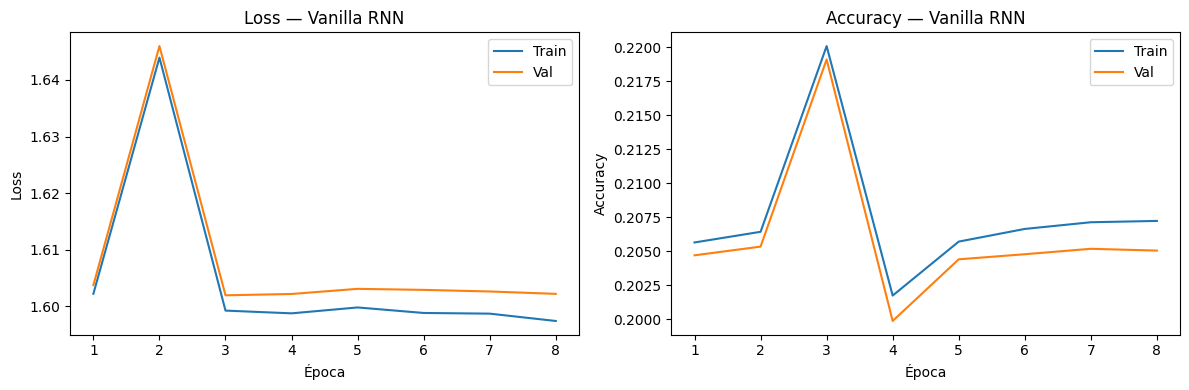

In [10]:
# ── Vanilla RNN ───────────────────────────────────────────────────────────────
print('=' * 60)
print('Vanilla RNN')
print('=' * 60)
hp = HP['RNN']
rnn_model = RecurrentClassifier(
    vocab_size=VOCAB_SIZE_RNN, embed_dim=hp['embed_dim'], hidden_dim=hp['hidden_dim'],
    num_classes=N_CLASSES, rnn_type='RNN', num_layers=hp['num_layers'], dropout=hp['dropout']
)
hist_rnn = train_model(rnn_model, seq_train_loader, seq_val_loader,
                       epochs=EPOCHS, lr=hp['lr'], patience=PATIENCE, label='RNN')
plot_history(hist_rnn, 'Vanilla RNN')

LSTM
[LSTM] Época   1/25  loss=1.5200  acc=0.2670  val_loss=1.5222  val_acc=0.2658  lr=1.00e-03  (66s)
[LSTM] Época   2/25  loss=1.5239  acc=0.2677  val_loss=1.5264  val_acc=0.2664  lr=1.00e-03  (122s)
[LSTM] Época   3/25  loss=1.5157  acc=0.2637  val_loss=1.5176  val_acc=0.2622  lr=1.00e-03  (179s)
[LSTM] Época   4/25  loss=1.5453  acc=0.2834  val_loss=1.5447  val_acc=0.2833  lr=1.00e-03  (236s)
[LSTM] Época   5/25  loss=1.5121  acc=0.2660  val_loss=1.5133  val_acc=0.2652  lr=1.00e-03  (292s)
[LSTM] Época   6/25  loss=1.5170  acc=0.2756  val_loss=1.5179  val_acc=0.2749  lr=1.00e-03  (343s)
[LSTM] Época   7/25  loss=1.5208  acc=0.2605  val_loss=1.5221  val_acc=0.2588  lr=1.00e-03  (398s)
[LSTM] Época   8/25  loss=1.5136  acc=0.2639  val_loss=1.5159  val_acc=0.2621  lr=1.00e-03  (450s)
[LSTM] Época   9/25  loss=1.5161  acc=0.2589  val_loss=1.5173  val_acc=0.2581  lr=5.00e-04  (502s)
[LSTM] Época  10/25  loss=1.5138  acc=0.2596  val_loss=1.5159  val_acc=0.2579  lr=5.00e-04  (554s)
  ↳ Ea

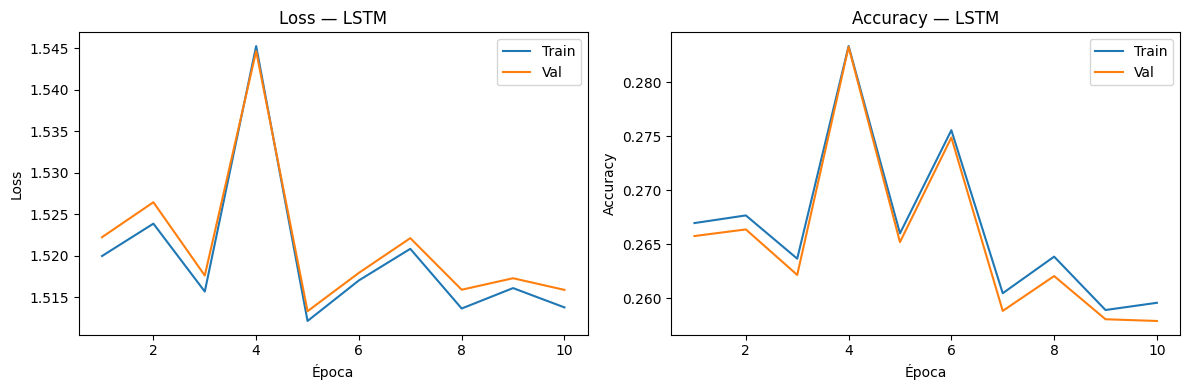

In [47]:
# ── LSTM ──────────────────────────────────────────────────────────────────────
print('=' * 60)
print('LSTM')
print('=' * 60)
hp = HP['LSTM']
lstm_model = RecurrentClassifier(
    vocab_size=VOCAB_SIZE_RNN, embed_dim=hp['embed_dim'], hidden_dim=hp['hidden_dim'],
    num_classes=N_CLASSES, rnn_type='LSTM', num_layers=hp['num_layers'], dropout=hp['dropout']
)
hist_lstm = train_model(lstm_model, seq_train_loader, seq_val_loader,
                        epochs=25, lr=hp['lr'], patience=PATIENCE, label='LSTM')
plot_history(hist_lstm, 'LSTM')

BiLSTM
[BiLSTM] Época   1/10  loss=0.5841  acc=0.7807  val_loss=0.6168  val_acc=0.7659  lr=1.00e-03  (70s)
[BiLSTM] Época   2/10  loss=0.4425  acc=0.8380  val_loss=0.5028  val_acc=0.8132  lr=1.00e-03  (139s)
[BiLSTM] Época   3/10  loss=0.3510  acc=0.8738  val_loss=0.4475  val_acc=0.8376  lr=1.00e-03  (208s)
[BiLSTM] Época   4/10  loss=0.2979  acc=0.8959  val_loss=0.4100  val_acc=0.8485  lr=1.00e-03  (276s)
[BiLSTM] Época   5/10  loss=0.2382  acc=0.9141  val_loss=0.4044  val_acc=0.8567  lr=1.00e-03  (345s)
[BiLSTM] Época   6/10  loss=0.1876  acc=0.9361  val_loss=0.3793  val_acc=0.8663  lr=1.00e-03  (414s)
[BiLSTM] Época   7/10  loss=0.1424  acc=0.9527  val_loss=0.3807  val_acc=0.8727  lr=1.00e-03  (485s)
[BiLSTM] Época   8/10  loss=0.1193  acc=0.9620  val_loss=0.4086  val_acc=0.8687  lr=1.00e-03  (554s)
[BiLSTM] Época   9/10  loss=0.0908  acc=0.9705  val_loss=0.4492  val_acc=0.8718  lr=1.00e-03  (626s)
[BiLSTM] Época  10/10  loss=0.0637  acc=0.9807  val_loss=0.4476  val_acc=0.8739  lr=5

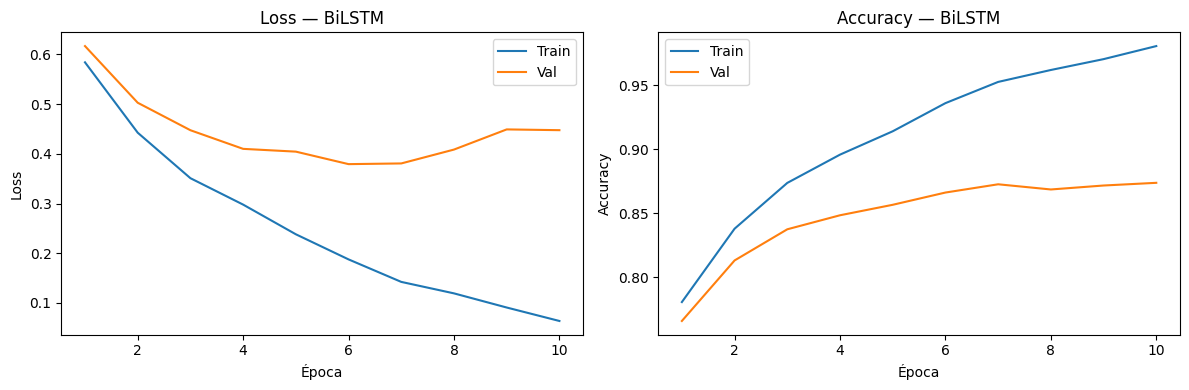

In [12]:
# ── BiLSTM ────────────────────────────────────────────────────────────────────
print('=' * 60)
print('BiLSTM')
print('=' * 60)
hp = HP['BiLSTM']
bilstm_model = RecurrentClassifier(
    vocab_size=VOCAB_SIZE_RNN, embed_dim=hp['embed_dim'], hidden_dim=hp['hidden_dim'],
    num_classes=N_CLASSES, rnn_type='LSTM', num_layers=hp['num_layers'],
    dropout=hp['dropout'], bidirectional=True
)
hist_bilstm = train_model(bilstm_model, seq_train_loader, seq_val_loader,
                          epochs=EPOCHS, lr=hp['lr'], patience=PATIENCE, label='BiLSTM')
plot_history(hist_bilstm, 'BiLSTM')

GRU
[GRU] Época   1/10  loss=0.8759  acc=0.6547  val_loss=0.8868  val_acc=0.6479  lr=1.00e-03  (32s)
[GRU] Época   2/10  loss=0.4230  acc=0.8441  val_loss=0.4702  val_acc=0.8221  lr=1.00e-03  (62s)
[GRU] Época   3/10  loss=0.2876  acc=0.8964  val_loss=0.3862  val_acc=0.8594  lr=1.00e-03  (90s)
[GRU] Época   4/10  loss=0.2120  acc=0.9270  val_loss=0.3526  val_acc=0.8735  lr=1.00e-03  (119s)
[GRU] Época   5/10  loss=0.1494  acc=0.9529  val_loss=0.3406  val_acc=0.8807  lr=1.00e-03  (149s)
[GRU] Época   6/10  loss=0.1246  acc=0.9590  val_loss=0.3806  val_acc=0.8745  lr=1.00e-03  (180s)
[GRU] Época   7/10  loss=0.0720  acc=0.9791  val_loss=0.3968  val_acc=0.8820  lr=1.00e-03  (210s)
[GRU] Época   8/10  loss=0.0523  acc=0.9848  val_loss=0.4395  val_acc=0.8801  lr=1.00e-03  (241s)
[GRU] Época   9/10  loss=0.0402  acc=0.9880  val_loss=0.4905  val_acc=0.8779  lr=5.00e-04  (270s)
[GRU] Época  10/10  loss=0.0170  acc=0.9959  val_loss=0.5802  val_acc=0.8844  lr=5.00e-04  (302s)
  ↳ Early stopping 

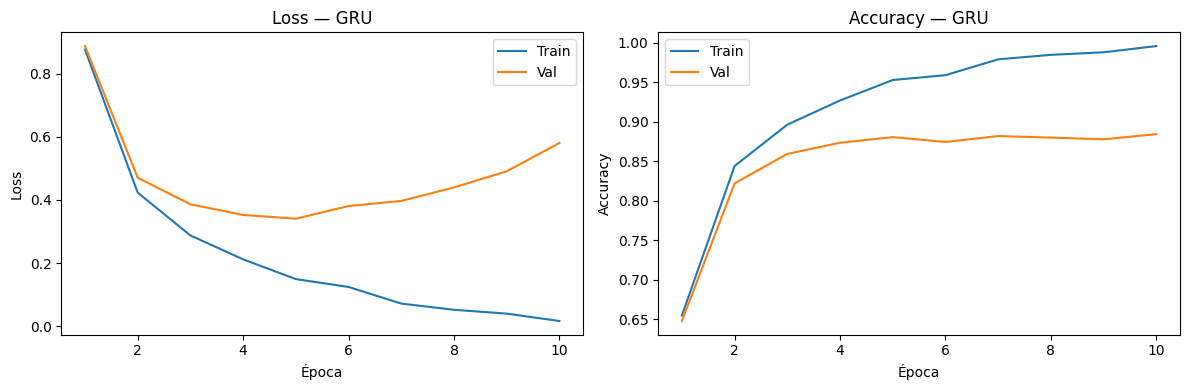

In [13]:
# ── GRU ───────────────────────────────────────────────────────────────────────
print('=' * 60)
print('GRU')
print('=' * 60)
hp = HP['GRU']
gru_model = RecurrentClassifier(
    vocab_size=VOCAB_SIZE_RNN, embed_dim=hp['embed_dim'], hidden_dim=hp['hidden_dim'],
    num_classes=N_CLASSES, rnn_type='GRU', num_layers=hp['num_layers'], dropout=hp['dropout']
)
hist_gru = train_model(gru_model, seq_train_loader, seq_val_loader,
                       epochs=EPOCHS, lr=hp['lr'], patience=PATIENCE, label='GRU')
plot_history(hist_gru, 'GRU')

## 5. Embeddings

Dois modelos adicionais baseados em embeddings:
- **EmbeddingMLP** — embeddings treináveis de raiz + mean-pooling + MLP (sem RNN)
- **BiLSTM-GloVe** — embeddings pré-treinados GloVe 6B 100d (fine-tuned) a alimentar uma BiLSTM

Com 50k exemplos por classe, o GloVe é **fine-tuned** (freeze=False) em vez de congelado.

In [14]:
# ═══════════════════════════════════════════════════════════════
# 5.1  EmbeddingMLP — embeddings treináveis + mean-pooling + MLP
# ═══════════════════════════════════════════════════════════════
class EmbeddingMLP(nn.Module):
    """
    Embedding(vocab, E) → mean-pool sobre T → Linear(E, H) → BN → ReLU → Dropout
                        → Linear(H, H//2) → BN → ReLU → Dropout → Linear(H//2, C)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        mask   = (x != 0).float().unsqueeze(-1)
        emb    = self.embedding(x)
        pooled = (emb * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.net(pooled)

print('EmbeddingMLP definido.')

EmbeddingMLP definido.


EmbeddingMLP
[EmbeddingMLP] Época   1/10  loss=0.6964  acc=0.7335  val_loss=0.7255  val_acc=0.7184  lr=1.00e-03  (7s)
[EmbeddingMLP] Época   2/10  loss=0.5449  acc=0.7930  val_loss=0.5999  val_acc=0.7716  lr=1.00e-03  (13s)
[EmbeddingMLP] Época   3/10  loss=0.4580  acc=0.8299  val_loss=0.5382  val_acc=0.7960  lr=1.00e-03  (19s)
[EmbeddingMLP] Época   4/10  loss=0.3980  acc=0.8543  val_loss=0.4996  val_acc=0.8135  lr=1.00e-03  (25s)
[EmbeddingMLP] Época   5/10  loss=0.3529  acc=0.8721  val_loss=0.4780  val_acc=0.8221  lr=1.00e-03  (32s)
[EmbeddingMLP] Época   6/10  loss=0.3145  acc=0.8871  val_loss=0.4664  val_acc=0.8271  lr=1.00e-03  (38s)
[EmbeddingMLP] Época   7/10  loss=0.2833  acc=0.9001  val_loss=0.4606  val_acc=0.8315  lr=1.00e-03  (44s)
[EmbeddingMLP] Época   8/10  loss=0.2595  acc=0.9083  val_loss=0.4625  val_acc=0.8332  lr=1.00e-03  (49s)
[EmbeddingMLP] Época   9/10  loss=0.2372  acc=0.9183  val_loss=0.4597  val_acc=0.8361  lr=1.00e-03  (55s)
[EmbeddingMLP] Época  10/10  loss=

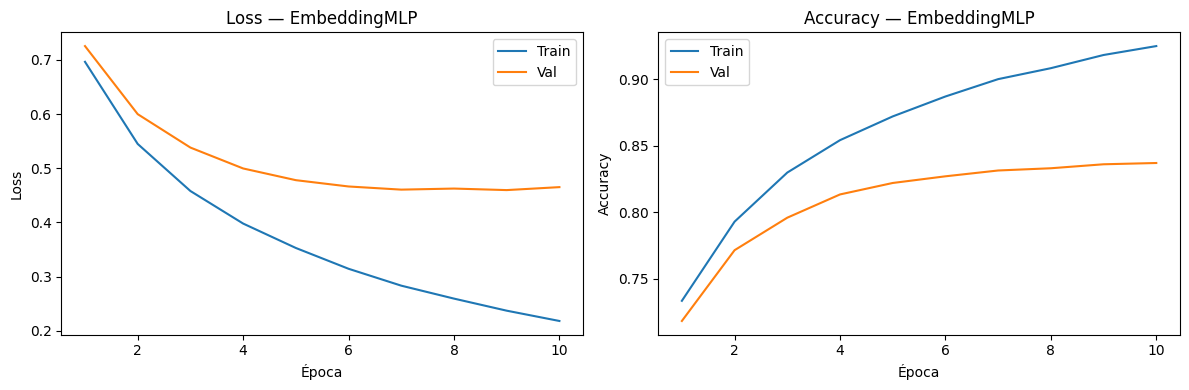

In [15]:
# ── EmbeddingMLP ──────────────────────────────────────────────────────────────
print('=' * 60)
print('EmbeddingMLP')
print('=' * 60)
hp = HP['EmbeddingMLP']
embed_mlp_model = EmbeddingMLP(
    VOCAB_SIZE_RNN, hp['embed_dim'], hp['hidden_dim'], N_CLASSES, hp['dropout'])
hist_embed = train_model(embed_mlp_model, seq_train_loader, seq_val_loader,
                         epochs=EPOCHS, lr=hp['lr'], patience=PATIENCE, label='EmbeddingMLP')
plot_history(hist_embed, 'EmbeddingMLP')

### 5.2 Embeddings Pre-treinados — GloVe 6B 100d

Carrega o ficheiro `glove.6B.100d.txt`.
Com 50k/classe temos dados suficientes para **fine-tuning** (freeze=False),
ao contrário do dataset anterior onde congelavamos para evitar overfitting.

In [16]:
import os, urllib.request, zipfile

# ── 1. Carregar / descarregar GloVe ──────────────────────────────────────────
GLOVE_PATH = 'glove.6B.100d.txt'
GLOVE_DIM  = 100

if not os.path.exists(GLOVE_PATH):
    print('A descarregar GloVe 6B (822 MB)...')
    url = 'https://nlp.stanford.edu/data/glove.6B.zip'
    urllib.request.urlretrieve(url, 'glove.6B.zip')
    with zipfile.ZipFile('glove.6B.zip') as z:
        z.extract('glove.6B.100d.txt')
    print('Download concluido.')

# ── 2. Construir matriz de embeddings para o vocab_rnn ────────────────────────
print('A carregar vectores GloVe...')
glove = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype=np.float32)

pretrained = np.zeros((VOCAB_SIZE_RNN, GLOVE_DIM), dtype=np.float32)
found = 0
for word, idx in vocab_rnn.items():
    if word in glove:
        pretrained[idx] = glove[word]
        found += 1
print(f'Palavras com vector GloVe: {found}/{VOCAB_SIZE_RNN}  ({100*found/VOCAB_SIZE_RNN:.1f}%)')

A carregar vectores GloVe...
Palavras com vector GloVe: 19119/20000  (95.6%)


BiLSTM-GloVe  (freeze=False — fine-tuning com 50k/classe)
[BiLSTM-GloVe] Época   1/10  loss=0.7384  acc=0.7095  val_loss=0.7541  val_acc=0.7014  lr=5.00e-04  (66s)
[BiLSTM-GloVe] Época   2/10  loss=0.5911  acc=0.7759  val_loss=0.6212  val_acc=0.7633  lr=5.00e-04  (130s)
[BiLSTM-GloVe] Época   3/10  loss=0.4788  acc=0.8192  val_loss=0.5206  val_acc=0.8004  lr=5.00e-04  (196s)
[BiLSTM-GloVe] Época   4/10  loss=0.4030  acc=0.8485  val_loss=0.4646  val_acc=0.8257  lr=5.00e-04  (256s)
[BiLSTM-GloVe] Época   5/10  loss=0.3341  acc=0.8794  val_loss=0.4062  val_acc=0.8474  lr=5.00e-04  (319s)
[BiLSTM-GloVe] Época   6/10  loss=0.2886  acc=0.8954  val_loss=0.3796  val_acc=0.8593  lr=5.00e-04  (404s)
[BiLSTM-GloVe] Época   7/10  loss=0.2677  acc=0.9011  val_loss=0.3891  val_acc=0.8603  lr=5.00e-04  (493s)
[BiLSTM-GloVe] Época   8/10  loss=0.2275  acc=0.9178  val_loss=0.3648  val_acc=0.8690  lr=5.00e-04  (585s)
[BiLSTM-GloVe] Época   9/10  loss=0.2157  acc=0.9214  val_loss=0.3913  val_acc=0.8677  

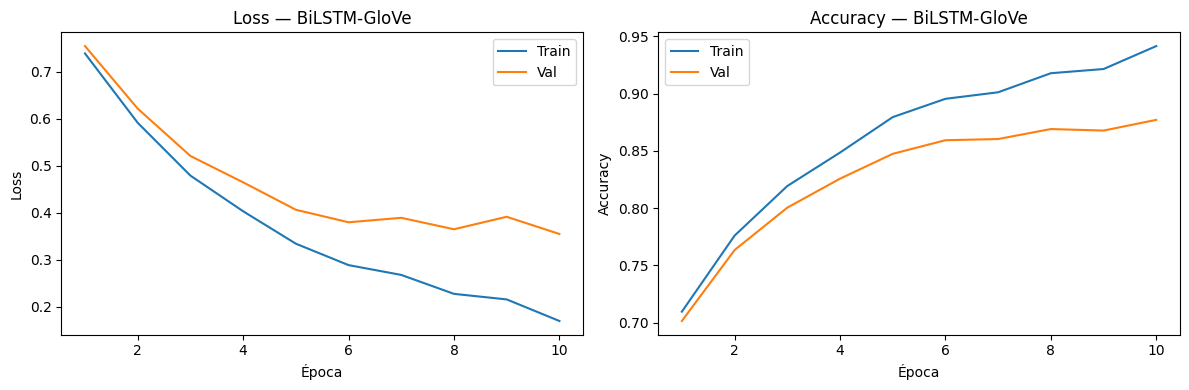

In [17]:
# ── BiLSTM-GloVe ──────────────────────────────────────────────────────────────
print('=' * 60)
print('BiLSTM-GloVe  (freeze=False — fine-tuning com 50k/classe)')
print('=' * 60)
hp = HP['BiLSTM-GloVe']
glove_bilstm_model = RecurrentClassifier(
    vocab_size=VOCAB_SIZE_RNN, embed_dim=GLOVE_DIM,
    hidden_dim=hp['hidden_dim'], num_classes=N_CLASSES,
    rnn_type='LSTM', num_layers=hp['num_layers'], dropout=hp['dropout'],
    bidirectional=True, pretrained_emb=pretrained
)
hist_glove = train_model(glove_bilstm_model, seq_train_loader, seq_val_loader,
                         epochs=EPOCHS, lr=hp['lr'], patience=PATIENCE, label='BiLSTM-GloVe')
plot_history(hist_glove, 'BiLSTM-GloVe')

## 6. Avaliação e Comparação de Modelos


╔══ Resultados no conjunto de TESTE ══╗
      Modelo  Accuracy  Macro-F1
         GRU  0.883893  0.883604
BiLSTM-GloVe  0.878240  0.879301
 FFNN-TF-IDF  0.877600  0.877290
    FFNN-BOW  0.869653  0.869585
      BiLSTM  0.868027  0.868066
EmbeddingMLP  0.838133  0.837903
        LSTM  0.579067  0.567902
 Vanilla RNN  0.217120  0.133773
╚══════════════════════════════════════╝


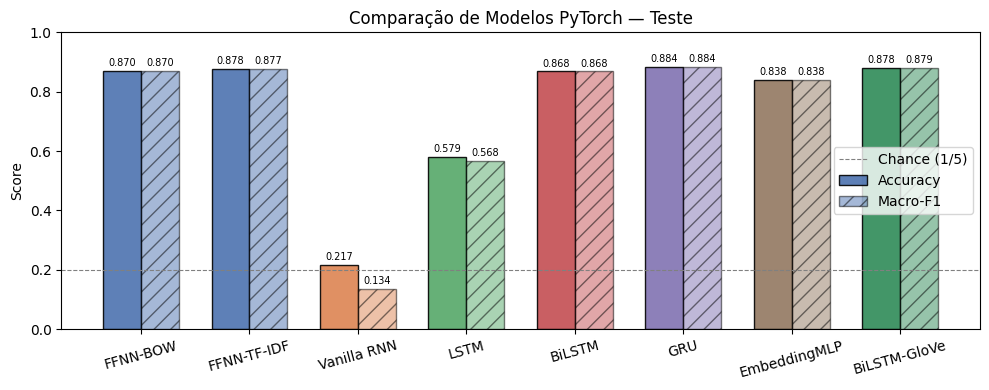

In [46]:
def eval_all(loader_map):
    """Devolve dict name→(acc, macro_f1, preds, targets) para cada modelo."""
    out = {}
    criterion = nn.CrossEntropyLoss()
    for name, (mdl, ldr) in loader_map.items():
        mdl.eval()
        preds, targets = [], []
        with torch.no_grad():
            for x, y in ldr:
                preds.extend(mdl(x.to(DEVICE)).argmax(1).cpu().tolist())
                targets.extend(y.tolist())
        acc = sum(p == t for p, t in zip(preds, targets)) / len(targets)
        f1  = sk_f1(targets, preds, average='macro', zero_division=0)
        out[name] = (acc, f1, preds, targets)
    return out


test_loader_map = {
    'FFNN-BOW':      (ffnn_bow,           bow_test_loader),
    'FFNN-TF-IDF':   (ffnn_tfidf,         tfidf_test_loader),
    'Vanilla RNN':   (rnn_model,          seq_test_loader),
    'LSTM':          (lstm_model,         seq_test_loader),
    'BiLSTM':        (bilstm_model,       seq_test_loader),
    'GRU':           (gru_model,          seq_test_loader),
    'EmbeddingMLP':  (embed_mlp_model,    seq_test_loader),
    'BiLSTM-GloVe':  (glove_bilstm_model, seq_test_loader),
}

test_evals = eval_all(test_loader_map)

# ── Tabela ───────────────────────────────────────────────────────────────────
rows = [{'Modelo': n, 'Accuracy': a, 'Macro-F1': f}
        for n, (a, f, _, _) in test_evals.items()]
df_res = pd.DataFrame(rows).sort_values('Macro-F1', ascending=False)
print('\n╔══ Resultados no conjunto de TESTE ══╗')
print(df_res.to_string(index=False))
print('╚══════════════════════════════════════╝')

# ── Gráfico barras duplas ─────────────────────────────────────────────────────
name_order = ['FFNN-BOW','FFNN-TF-IDF','Vanilla RNN','LSTM','BiLSTM','GRU','EmbeddingMLP','BiLSTM-GloVe']
color_map  = dict(zip(name_order,
                      ['#4C72B0','#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#2E8B57']))
nomes      = [r['Modelo'] for r in rows]
accs       = [r['Accuracy'] for r in rows]
f1s        = [r['Macro-F1'] for r in rows]
bar_colors = [color_map.get(n, '#888888') for n in nomes]

x, w = range(len(nomes)), 0.35
fig, ax = plt.subplots(figsize=(10, 4))
b1 = ax.bar([i - w/2 for i in x], accs, w, label='Accuracy',
            color=bar_colors, alpha=0.90, edgecolor='black')
b2 = ax.bar([i + w/2 for i in x], f1s,  w, label='Macro-F1',
            color=bar_colors, alpha=0.50, edgecolor='black', hatch='//')
ax.set_xticks(list(x)); ax.set_xticklabels(nomes, rotation=15)
ax.set(ylim=(0, 1), ylabel='Score', title='Comparação de Modelos PyTorch — Teste')
ax.axhline(1/N_CLASSES, color='grey', linestyle='--', lw=0.8, label=f'Chance (1/{N_CLASSES})')
for bar, val in zip(list(b1)+list(b2), accs+f1s):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7)
ax.legend(); plt.tight_layout(); plt.show()

Melhor modelo individual: GRU  (acc=0.8839)


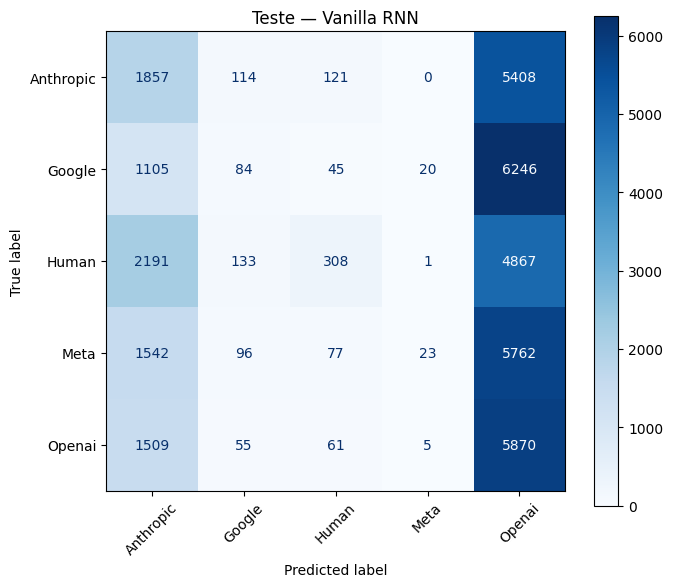

              precision    recall  f1-score   support

   Anthropic     0.2264    0.2476    0.2365      7500
      Google     0.1743    0.0112    0.0210      7500
       Human     0.5033    0.0411    0.0759      7500
        Meta     0.4694    0.0031    0.0061      7500
      Openai     0.2085    0.7827    0.3293      7500

    accuracy                         0.2171     37500
   macro avg     0.3164    0.2171    0.1338     37500
weighted avg     0.3164    0.2171    0.1338     37500



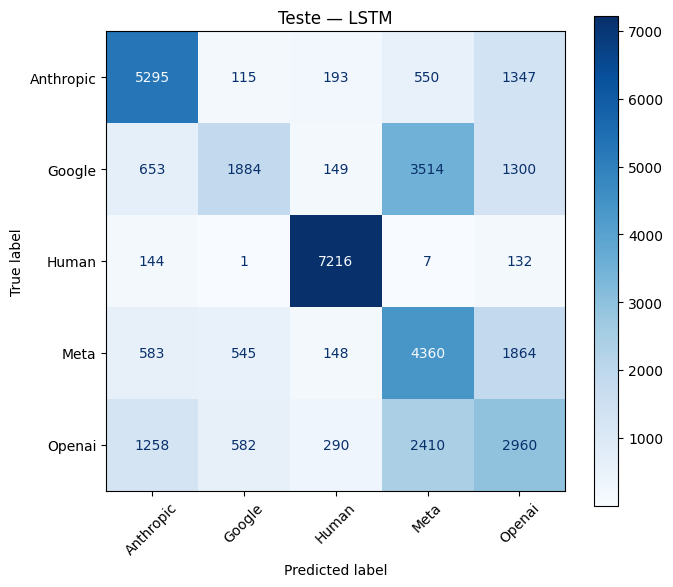

              precision    recall  f1-score   support

   Anthropic     0.6675    0.7060    0.6862      7500
      Google     0.6025    0.2512    0.3546      7500
       Human     0.9025    0.9621    0.9313      7500
        Meta     0.4022    0.5813    0.4754      7500
      Openai     0.3893    0.3947    0.3920      7500

    accuracy                         0.5791     37500
   macro avg     0.5928    0.5791    0.5679     37500
weighted avg     0.5928    0.5791    0.5679     37500



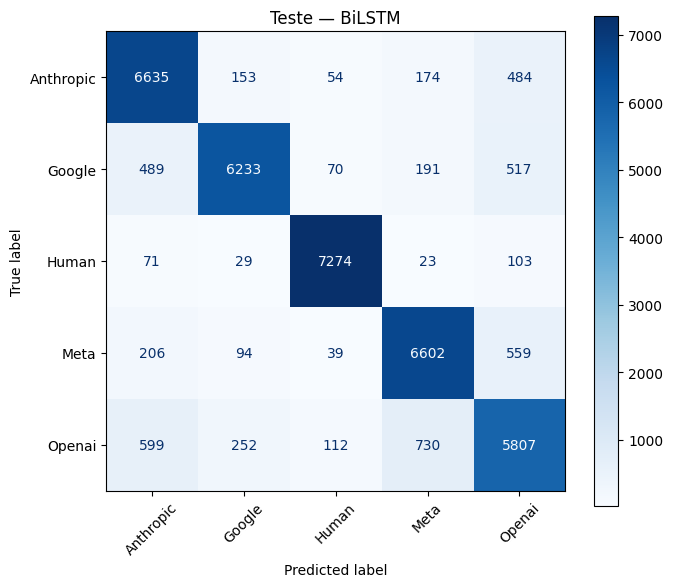

              precision    recall  f1-score   support

   Anthropic     0.8294    0.8847    0.8561      7500
      Google     0.9219    0.8311    0.8741      7500
       Human     0.9636    0.9699    0.9667      7500
        Meta     0.8552    0.8803    0.8675      7500
      Openai     0.7774    0.7743    0.7758      7500

    accuracy                         0.8680     37500
   macro avg     0.8695    0.8680    0.8681     37500
weighted avg     0.8695    0.8680    0.8681     37500



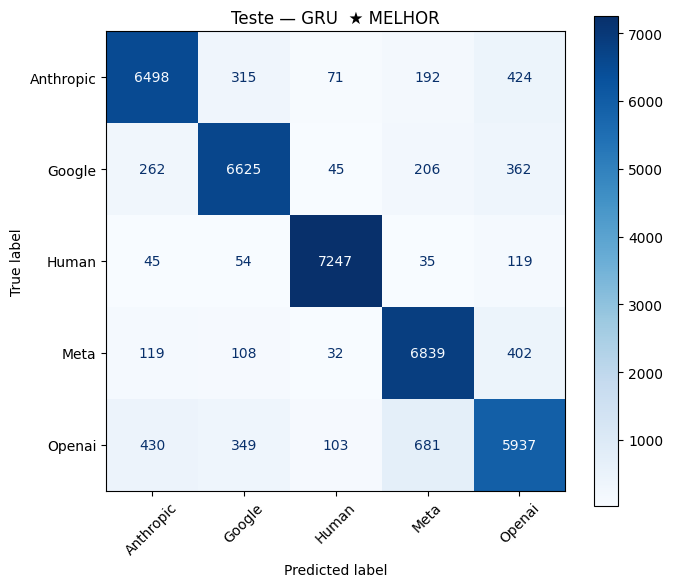

              precision    recall  f1-score   support

   Anthropic     0.8836    0.8664    0.8749      7500
      Google     0.8891    0.8833    0.8862      7500
       Human     0.9665    0.9663    0.9664      7500
        Meta     0.8599    0.9119    0.8851      7500
      Openai     0.8196    0.7916    0.8053      7500

    accuracy                         0.8839     37500
   macro avg     0.8838    0.8839    0.8836     37500
weighted avg     0.8838    0.8839    0.8836     37500



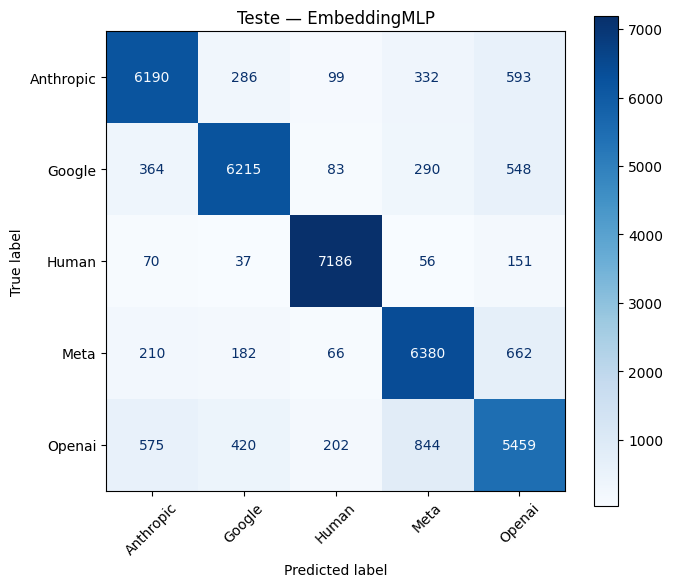

              precision    recall  f1-score   support

   Anthropic     0.8355    0.8253    0.8304      7500
      Google     0.8704    0.8287    0.8490      7500
       Human     0.9411    0.9581    0.9495      7500
        Meta     0.8074    0.8507    0.8285      7500
      Openai     0.7364    0.7279    0.7321      7500

    accuracy                         0.8381     37500
   macro avg     0.8382    0.8381    0.8379     37500
weighted avg     0.8382    0.8381    0.8379     37500



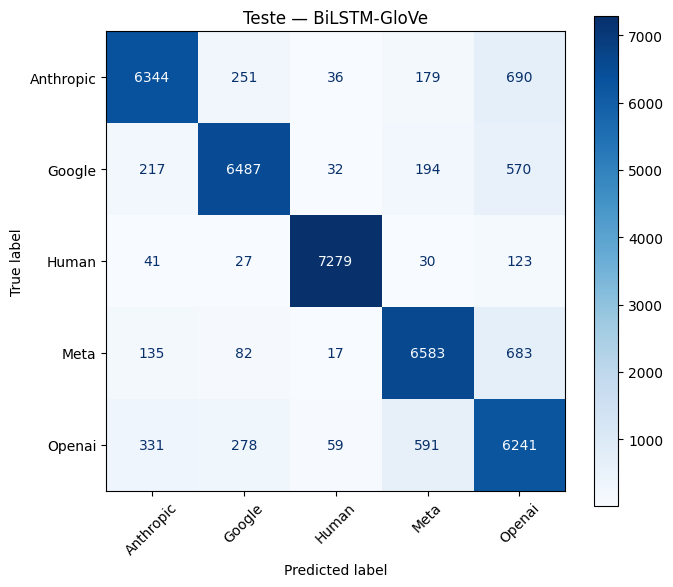

              precision    recall  f1-score   support

   Anthropic     0.8976    0.8459    0.8710      7500
      Google     0.9105    0.8649    0.8871      7500
       Human     0.9806    0.9705    0.9755      7500
        Meta     0.8688    0.8777    0.8733      7500
      Openai     0.7513    0.8321    0.7897      7500

    accuracy                         0.8782     37500
   macro avg     0.8817    0.8782    0.8793     37500
weighted avg     0.8817    0.8782    0.8793     37500



In [20]:
# ── Matrizes de confusão — todos os modelos ──────────────────────────────────
acc_map   = {n: v[0] for n, v in test_evals.items()}
best_name = max(acc_map, key=acc_map.get)
print(f'Melhor modelo individual: {best_name}  (acc={acc_map[best_name]:.4f})')

for name, (mdl, ldr) in test_loader_map.items():
    marker = '  ★ MELHOR' if name == best_name else ''
    plot_confusion(mdl, ldr, title=f'Teste — {name}{marker}')

## 6.5 Ensemble — Média de Probabilidades

Combina as previsões dos 8 modelos por **média das probabilidades softmax**.
São testadas três estratégias: média simples, média ponderada por accuracy, Top-3.

In [21]:
def get_proba(model, loader):
    model.eval()
    all_proba, all_targets = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            proba  = torch.softmax(logits, dim=1).cpu().numpy()
            all_proba.append(proba)
            all_targets.extend(y.tolist())
    return np.vstack(all_proba), np.array(all_targets)

probas = {}
for name, (mdl, ldr) in test_loader_map.items():
    probas[name], targets_test = get_proba(mdl, ldr)

weights = np.array([acc_map[n] for n in test_loader_map.keys()])
weights = weights / weights.sum()

def ensemble_predict(probas_dict, loader_keys, w=None):
    stack = np.stack([probas_dict[k] for k in loader_keys], axis=0)
    avg   = (np.tensordot(w / w.sum(), stack, axes=([0], [0]))
             if w is not None else stack.mean(axis=0))
    preds = avg.argmax(axis=1)
    acc   = (preds == targets_test).mean()
    f1    = sk_f1(targets_test, preds, average='macro', zero_division=0)
    return preds, acc, f1

preds_ens_simple,   acc_ens_simple,   f1_ens_simple   = ensemble_predict(probas, list(test_loader_map.keys()))
preds_ens_weighted, acc_ens_weighted, f1_ens_weighted = ensemble_predict(probas, list(test_loader_map.keys()), w=weights)
top3_names = sorted(acc_map, key=acc_map.get, reverse=True)[:3]
preds_ens_top3,     acc_ens_top3,     f1_ens_top3     = ensemble_predict(probas, top3_names)

print('\n╔══ Ensemble vs Modelos Individuais (TESTE) ══╗')
print(f'{"Modelo":<28} {"Accuracy":>10} {"Macro-F1":>10}')
print('-' * 52)
for n, (a, f, _, _) in test_evals.items():
    print(f'{n:<28} {a:>10.4f} {f:>10.4f}')
print('-' * 52)
print(f'{"Ensemble Simples":<28} {acc_ens_simple:>10.4f} {f1_ens_simple:>10.4f}')
print(f'{"Ensemble Ponderado":<28} {acc_ens_weighted:>10.4f} {f1_ens_weighted:>10.4f}')
print(f'{f"Ensemble Top-3 ({chr(44).join(top3_names)})":<28} {acc_ens_top3:>10.4f} {f1_ens_top3:>10.4f}')
print('╚══════════════════════════════════════════════╝')


╔══ Ensemble vs Modelos Individuais (TESTE) ══╗
Modelo                         Accuracy   Macro-F1
----------------------------------------------------
Vanilla RNN                      0.2171     0.1338
LSTM                             0.5791     0.5679
BiLSTM                           0.8680     0.8681
GRU                              0.8839     0.8836
EmbeddingMLP                     0.8381     0.8379
BiLSTM-GloVe                     0.8782     0.8793
----------------------------------------------------
Ensemble Simples                 0.9033     0.9034
Ensemble Ponderado               0.9043     0.9044
Ensemble Top-3 (GRU,BiLSTM-GloVe,BiLSTM)     0.9035     0.9037
╚══════════════════════════════════════════════╝


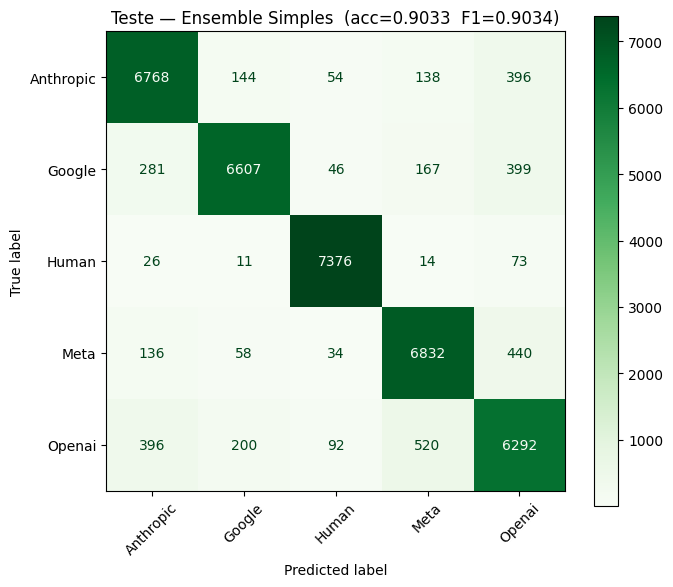

              precision    recall  f1-score   support

   Anthropic     0.8897    0.9024    0.8960      7500
      Google     0.9412    0.8809    0.9101      7500
       Human     0.9703    0.9835    0.9768      7500
        Meta     0.8906    0.9109    0.9007      7500
      Openai     0.8279    0.8389    0.8334      7500

    accuracy                         0.9033     37500
   macro avg     0.9039    0.9033    0.9034     37500
weighted avg     0.9039    0.9033    0.9034     37500



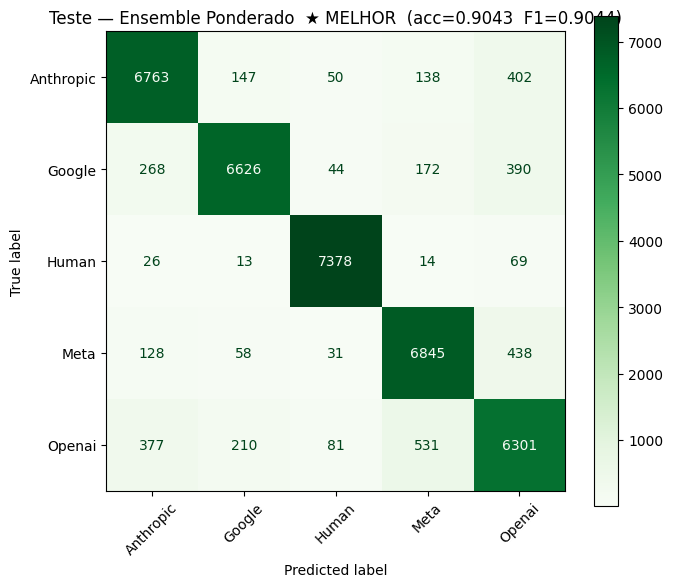

              precision    recall  f1-score   support

   Anthropic     0.8943    0.9017    0.8980      7500
      Google     0.9393    0.8835    0.9105      7500
       Human     0.9728    0.9837    0.9783      7500
        Meta     0.8890    0.9127    0.9007      7500
      Openai     0.8291    0.8401    0.8346      7500

    accuracy                         0.9043     37500
   macro avg     0.9049    0.9043    0.9044     37500
weighted avg     0.9049    0.9043    0.9044     37500



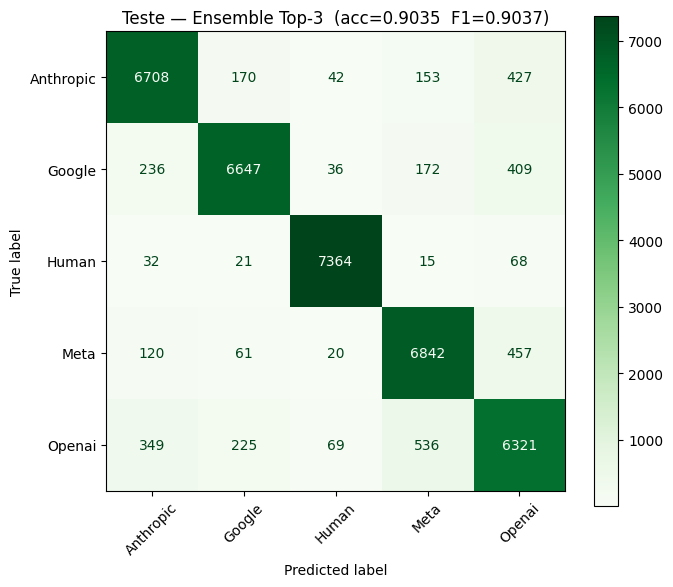

              precision    recall  f1-score   support

   Anthropic     0.9010    0.8944    0.8977      7500
      Google     0.9330    0.8863    0.9091      7500
       Human     0.9778    0.9819    0.9798      7500
        Meta     0.8865    0.9123    0.8992      7500
      Openai     0.8228    0.8428    0.8327      7500

    accuracy                         0.9035     37500
   macro avg     0.9042    0.9035    0.9037     37500
weighted avg     0.9042    0.9035    0.9037     37500


★ Ensemble Ponderado (0.9043) supera o melhor individual (GRU: 0.8839)


In [22]:
# ── Matrizes de confusão dos ensembles ───────────────────────────────────────
ensemble_results = {
    'Ensemble Simples':   (acc_ens_simple,   f1_ens_simple,   preds_ens_simple),
    'Ensemble Ponderado': (acc_ens_weighted,  f1_ens_weighted, preds_ens_weighted),
    'Ensemble Top-3':     (acc_ens_top3,      f1_ens_top3,     preds_ens_top3),
}
best_ens_name = max(ensemble_results, key=lambda k: ensemble_results[k][1])
lbls = [IDX_TO_CLASS[i] for i in range(N_CLASSES)]

for ens_name, (ens_acc, ens_f1, ens_preds) in ensemble_results.items():
    marker = '  ★ MELHOR' if ens_name == best_ens_name else ''
    cm = confusion_matrix(targets_test, ens_preds)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=lbls).plot(
        ax=ax, xticks_rotation=45, cmap='Greens', values_format='d')
    ax.set_title(f'Teste — {ens_name}{marker}  (acc={ens_acc:.4f}  F1={ens_f1:.4f})')
    plt.tight_layout(); plt.show()
    print(classification_report(targets_test, ens_preds, target_names=lbls, digits=4))

best_individual_acc  = max(acc_map.values())
best_individual_name = max(acc_map, key=acc_map.get)
best_ens_acc         = ensemble_results[best_ens_name][0]

if best_ens_acc >= best_individual_acc:
    print(f'\n★ {best_ens_name} ({best_ens_acc:.4f}) supera o melhor individual'
          f' ({best_individual_name}: {best_individual_acc:.4f})')
    best_model_to_save     = None
    best_model_name_global = best_ens_name
else:
    print(f'\nMelhor modelo individual ({best_individual_name}: {best_individual_acc:.4f})'
          f' supera o melhor ensemble ({best_ens_name}: {best_ens_acc:.4f})')
    best_model_to_save     = test_loader_map[best_individual_name][0]
    best_model_name_global = best_individual_name

## 7. Guardar o Melhor Modelo

In [ ]:
import os
OUT = os.getcwd()

all_models_dict = {
    'FFNN-BOW':      ffnn_bow,
    'FFNN-TF-IDF':   ffnn_tfidf,
    'Vanilla-RNN':   rnn_model,
    'LSTM':          lstm_model,
    'BiLSTM':        bilstm_model,
    'GRU':           gru_model,
    'EmbeddingMLP':  embed_mlp_model,
    'BiLSTM-GloVe':  glove_bilstm_model,
}
all_states = {name: mdl.state_dict() for name, mdl in all_models_dict.items()}
torch.save(all_states, os.path.join(OUT, 'torch_all_models.pth'))
print('  Todos os modelos individuais guardados: torch_all_models.pth')

if best_model_to_save is not None:
    torch.save(best_model_to_save.state_dict(),
               os.path.join(OUT, 'torch_best_model.pth'))
    print(f'  Melhor modelo ({best_model_name_global}) guardado: torch_best_model.pth')
else:
    print(f'  Melhor modelo é {best_model_name_global} (ensemble).')
    ensemble_weights = {n: float(acc_map[n]) for n in test_loader_map.keys()}
    with open(os.path.join(OUT, 'torch_ensemble_weights.pkl'), 'wb') as f:
        pickle.dump(ensemble_weights, f)
    print('  Pesos do ensemble guardados: torch_ensemble_weights.pkl')

with open(os.path.join(OUT, 'torch_word_index.pkl'), 'wb') as f:
    pickle.dump(vocab_rnn, f)
with open(os.path.join(OUT, 'torch_word_index_bow.pkl'), 'wb') as f:
    pickle.dump(vocab_bow, f)
with open(os.path.join(OUT, 'torch_idx2label.pkl'), 'wb') as f:
    pickle.dump(IDX_TO_CLASS, f)
with open(os.path.join(OUT, 'torch_tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vec, f)

print(f'  Vocab RNN: torch_word_index.pkl  ({VOCAB_SIZE_RNN} tokens)')
print(f'  Vocab BOW: torch_word_index_bow.pkl  ({VOCAB_SIZE_FFNN} tokens)')
print(f'  Labels:    torch_idx2label.pkl  {IDX_TO_CLASS}')
print(f'  TF-IDF:    torch_tfidf_vectorizer.pkl  (bigramas, {MAX_WORDS_FFNN} features)')
print(f'\n  Melhor modelo global: {best_model_name_global}')

  Todos os modelos individuais guardados: torch_all_models.pth
  Melhor modelo é Ensemble Ponderado (ensemble).
  Pesos do ensemble guardados: torch_ensemble_weights.pkl
  Vocab RNN: torch_word_index.pkl  (20000 tokens)
  Vocab BOW: torch_word_index_bow.pkl  (10000 tokens)
  Labels:    torch_idx2label.pkl  {0: 'Anthropic', 1: 'Google', 2: 'Human', 3: 'Meta', 4: 'Openai'}
  TF-IDF:    torch_tfidf_vectorizer.pkl  (bigramas, 10000 features)

  Melhor modelo global: Ensemble Ponderado


## 8. Teste no Dataset Externo (`dataset-exemplos.csv`)

Avalia **todos** os modelos em 125 exemplos novos (nunca vistos no treino).

In [41]:
# ── Carregar CSV ──────────────────────────────────────────────────────────────
CSV_PATH = 'dataset-exemplos.csv'
df_ext = pd.read_csv(CSV_PATH, sep=';')
df_ext.columns = df_ext.columns.str.strip()
df_ext['Text']  = df_ext['Text'].astype(str).apply(clean_text)

# Normalizar para lowercase em ambos os lados — resolve 'OpenAI' vs 'Openai'
label_map_lower = {k.lower(): v for k, v in CLASS_TO_IDX.items()}
df_ext['label_lower'] = df_ext['Label'].str.lower().str.strip()
df_ext = df_ext[df_ext['label_lower'].isin(label_map_lower)].copy()
df_ext['label_id'] = df_ext['label_lower'].map(label_map_lower)

X_ext = df_ext['Text'].tolist()
y_ext = df_ext['label_id'].tolist()
print(f'Registos carregados: {len(df_ext)}')
print(df_ext['label_lower'].value_counts().to_string())

Registos carregados: 125
label_lower
human        52
anthropic    23
meta         17
openai       17
google       16


In [42]:
# ── DataLoaders externos ─────────────────────────────────────────────────────
bow_ext_loader   = DataLoader(BOWDataset(X_ext, y_ext, vocab_bow, VOCAB_SIZE_FFNN), BATCH_SIZE)
X_tf_ext_sp      = tfidf_vec.transform(X_ext)          # manter esparso
y_ext_tensor     = torch.tensor(y_ext, dtype=torch.long)
tfidf_ext_loader = DataLoader(SparseDataset(X_tf_ext_sp, y_ext_tensor), BATCH_SIZE)
seq_ext_loader   = DataLoader(SequenceDataset(X_ext, y_ext, vocab_rnn, MAX_LEN), BATCH_SIZE)
print('DataLoaders externos prontos.')


  A pré-computar BOW (125 textos)... pronto em 0.0s
  A pré-computar sequências (125 textos)... pronto em 0.0s
DataLoaders externos prontos.


In [43]:
# ── Avaliar todos os modelos no dataset externo ───────────────────────────────
def get_preds(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.extend(model(x.to(DEVICE)).argmax(1).cpu().tolist())
            targets.extend(y.tolist())
    return preds, targets

ext_loader_map = {
    'FFNN-BOW':      (ffnn_bow,           bow_ext_loader),
    'FFNN-TF-IDF':   (ffnn_tfidf,         tfidf_ext_loader),
    'Vanilla RNN':   (rnn_model,          seq_ext_loader),
    'LSTM':          (lstm_model,         seq_ext_loader),
    'BiLSTM':        (bilstm_model,       seq_ext_loader),
    'GRU':           (gru_model,          seq_ext_loader),
    'EmbeddingMLP':  (embed_mlp_model,    seq_ext_loader),
    'BiLSTM-GloVe':  (glove_bilstm_model, seq_ext_loader),
}

ext_results, ext_pred_map, ext_proba_map = [], {}, {}

print(f'{"Modelo":<20} {"Accuracy":>10} {"Macro-F1":>10}')
print('-' * 43)
for name, (mdl, ldr) in ext_loader_map.items():
    preds, targets_ext = get_preds(mdl, ldr)
    proba, _           = get_proba(mdl, ldr)
    acc = sum(p == t for p, t in zip(preds, targets_ext)) / len(targets_ext)
    f1  = sk_f1(targets_ext, preds, average='macro', zero_division=0)
    ext_results.append({'Modelo': name, 'Accuracy': acc, 'Macro-F1': f1})
    ext_pred_map[name]  = (preds, targets_ext)
    ext_proba_map[name] = proba
    print(f'{name:<20} {acc:>10.4f} {f1:>10.4f}')

targets_ext_arr = np.array(targets_ext)
ext_acc_map     = {r['Modelo']: r['Accuracy'] for r in ext_results}
ext_weights     = np.array([ext_acc_map[n] for n in ext_loader_map.keys()])
ext_weights     = ext_weights / ext_weights.sum()

def ensemble_ext(names, w=None):
    stack = np.stack([ext_proba_map[k] for k in names], axis=0)
    avg   = (np.tensordot(w/w.sum(), stack, axes=([0],[0]))
             if w is not None else stack.mean(axis=0))
    preds = avg.argmax(axis=1)
    acc   = (preds == targets_ext_arr).mean()
    f1    = sk_f1(targets_ext_arr, preds, average='macro', zero_division=0)
    return preds, acc, f1

_, acc_ext_simple,   f1_ext_simple   = ensemble_ext(list(ext_loader_map.keys()))
_, acc_ext_weighted, f1_ext_weighted = ensemble_ext(list(ext_loader_map.keys()), w=ext_weights)
top3_ext = sorted(ext_acc_map, key=ext_acc_map.get, reverse=True)[:3]
_, acc_ext_top3,     f1_ext_top3     = ensemble_ext(top3_ext)

print('-' * 43)
print(f'{"Ensemble Simples":<20} {acc_ext_simple:>10.4f} {f1_ext_simple:>10.4f}')
print(f'{"Ensemble Ponderado":<20} {acc_ext_weighted:>10.4f} {f1_ext_weighted:>10.4f}')
print(f'{"Ensemble Top-3":<20} {acc_ext_top3:>10.4f} {f1_ext_top3:>10.4f}')

df_ext_res = pd.DataFrame(ext_results).sort_values('Macro-F1', ascending=False)
print('\n╔══ Resultados no Dataset Externo (125 exemplos) ══╗')
print(df_ext_res.to_string(index=False))
print('╚══════════════════════════════════════════════════╝')

Modelo                 Accuracy   Macro-F1
-------------------------------------------
FFNN-BOW                 0.4640     0.4522
FFNN-TF-IDF              0.4880     0.4510
Vanilla RNN              0.1360     0.0866
LSTM                     0.3360     0.2598
BiLSTM                   0.2560     0.2551
GRU                      0.4480     0.4635
EmbeddingMLP             0.4480     0.4618
BiLSTM-GloVe             0.3600     0.3708
-------------------------------------------
Ensemble Simples         0.4480     0.4727
Ensemble Ponderado       0.4720     0.4914
Ensemble Top-3           0.4960     0.4918

╔══ Resultados no Dataset Externo (125 exemplos) ══╗
      Modelo  Accuracy  Macro-F1
         GRU     0.448  0.463510
EmbeddingMLP     0.448  0.461771
    FFNN-BOW     0.464  0.452212
 FFNN-TF-IDF     0.488  0.451003
BiLSTM-GloVe     0.360  0.370839
        LSTM     0.336  0.259786
      BiLSTM     0.256  0.255061
 Vanilla RNN     0.136  0.086643
╚════════════════════════════════════════════

In [44]:
# ── Relatório detalhado por classe — todos os modelos ─────────────────────────
lbls = [IDX_TO_CLASS[i] for i in range(N_CLASSES)]
for name, (preds, targets) in ext_pred_map.items():
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(targets, preds, target_names=lbls, digits=4, zero_division=0))


  FFNN-BOW
              precision    recall  f1-score   support

   Anthropic     0.3030    0.4348    0.3571        23
      Google     0.3913    0.5625    0.4615        16
       Human     1.0000    0.4808    0.6494        52
        Meta     0.7000    0.4118    0.5185        17
      Openai     0.2059    0.4118    0.2745        17

    accuracy                         0.4640       125
   macro avg     0.5200    0.4603    0.4522       125
weighted avg     0.6450    0.4640    0.5028       125


  FFNN-TF-IDF
              precision    recall  f1-score   support

   Anthropic     0.3438    0.4783    0.4000        23
      Google     0.3750    0.5625    0.4500        16
       Human     0.9062    0.5577    0.6905        52
        Meta     0.7143    0.2941    0.4167        17
      Openai     0.2333    0.4118    0.2979        17

    accuracy                         0.4880       125
   macro avg     0.5145    0.4609    0.4510       125
weighted avg     0.6171    0.4880    0.5156       

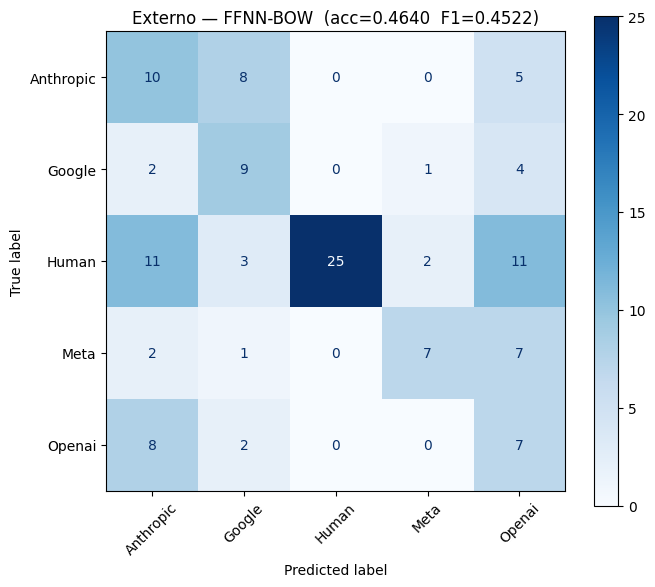

              precision    recall  f1-score   support

   Anthropic     0.3030    0.4348    0.3571        23
      Google     0.3913    0.5625    0.4615        16
       Human     1.0000    0.4808    0.6494        52
        Meta     0.7000    0.4118    0.5185        17
      Openai     0.2059    0.4118    0.2745        17

    accuracy                         0.4640       125
   macro avg     0.5200    0.4603    0.4522       125
weighted avg     0.6450    0.4640    0.5028       125



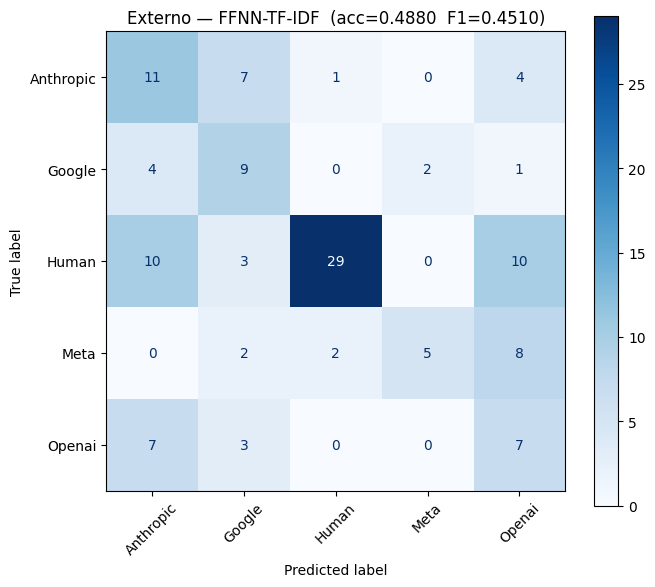

              precision    recall  f1-score   support

   Anthropic     0.3438    0.4783    0.4000        23
      Google     0.3750    0.5625    0.4500        16
       Human     0.9062    0.5577    0.6905        52
        Meta     0.7143    0.2941    0.4167        17
      Openai     0.2333    0.4118    0.2979        17

    accuracy                         0.4880       125
   macro avg     0.5145    0.4609    0.4510       125
weighted avg     0.6171    0.4880    0.5156       125



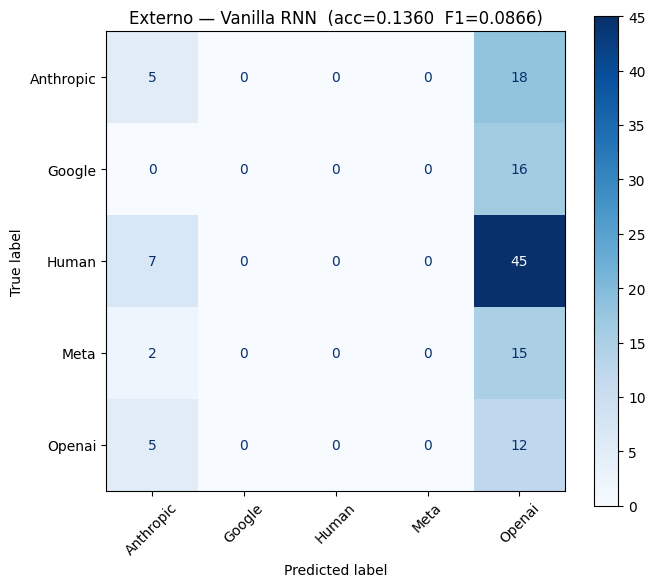

              precision    recall  f1-score   support

   Anthropic     0.2632    0.2174    0.2381        23
      Google     0.0000    0.0000    0.0000        16
       Human     0.0000    0.0000    0.0000        52
        Meta     0.0000    0.0000    0.0000        17
      Openai     0.1132    0.7059    0.1951        17

    accuracy                         0.1360       125
   macro avg     0.0753    0.1847    0.0866       125
weighted avg     0.0638    0.1360    0.0703       125



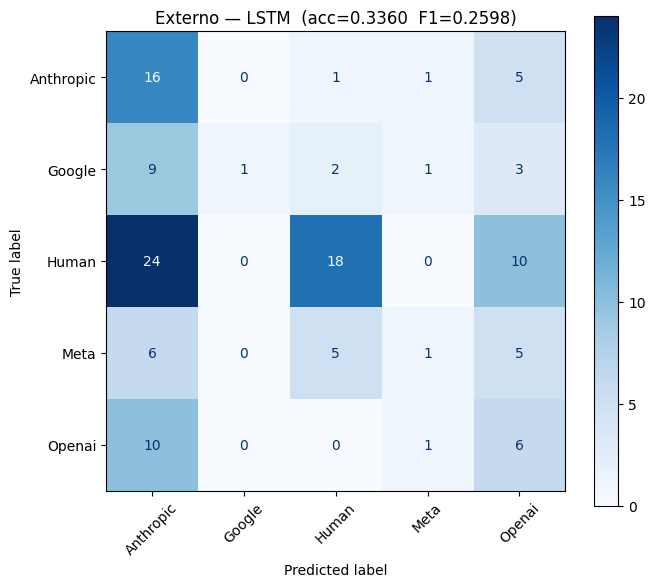

              precision    recall  f1-score   support

   Anthropic     0.2462    0.6957    0.3636        23
      Google     1.0000    0.0625    0.1176        16
       Human     0.6923    0.3462    0.4615        52
        Meta     0.2500    0.0588    0.0952        17
      Openai     0.2069    0.3529    0.2609        17

    accuracy                         0.3360       125
   macro avg     0.4791    0.3032    0.2598       125
weighted avg     0.5234    0.3360    0.3224       125



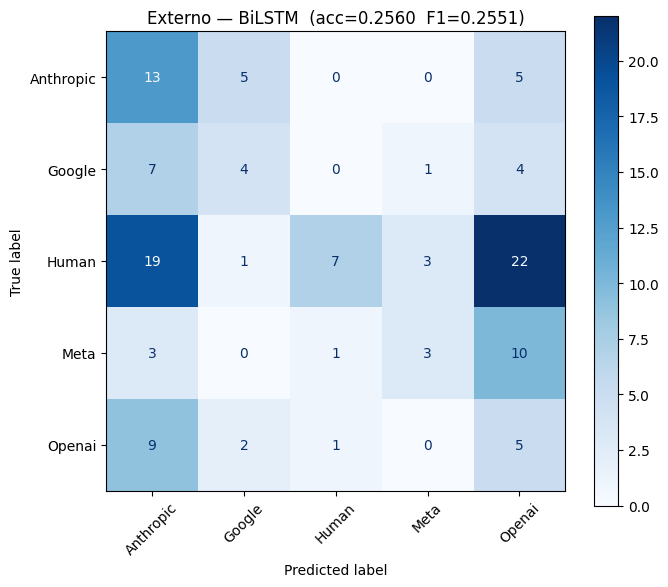

              precision    recall  f1-score   support

   Anthropic     0.2549    0.5652    0.3514        23
      Google     0.3333    0.2500    0.2857        16
       Human     0.7778    0.1346    0.2295        52
        Meta     0.4286    0.1765    0.2500        17
      Openai     0.1087    0.2941    0.1587        17

    accuracy                         0.2560       125
   macro avg     0.3807    0.2841    0.2551       125
weighted avg     0.4862    0.2560    0.2523       125



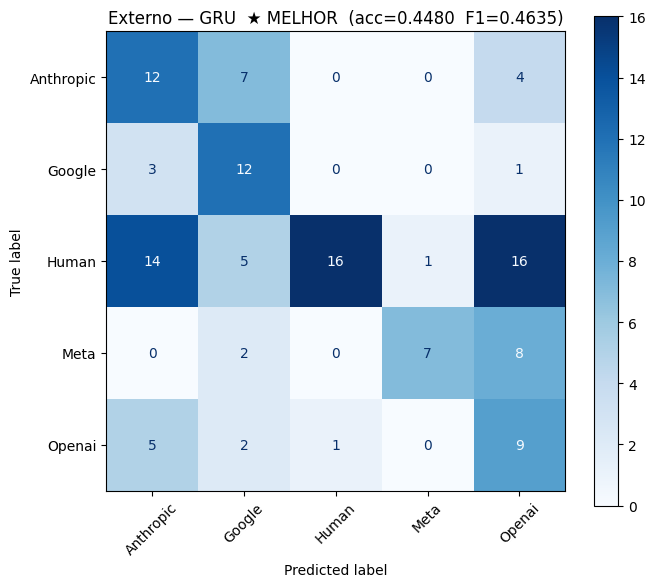

              precision    recall  f1-score   support

   Anthropic     0.3529    0.5217    0.4211        23
      Google     0.4286    0.7500    0.5455        16
       Human     0.9412    0.3077    0.4638        52
        Meta     0.8750    0.4118    0.5600        17
      Openai     0.2368    0.5294    0.3273        17

    accuracy                         0.4480       125
   macro avg     0.5669    0.5041    0.4635       125
weighted avg     0.6625    0.4480    0.4609       125



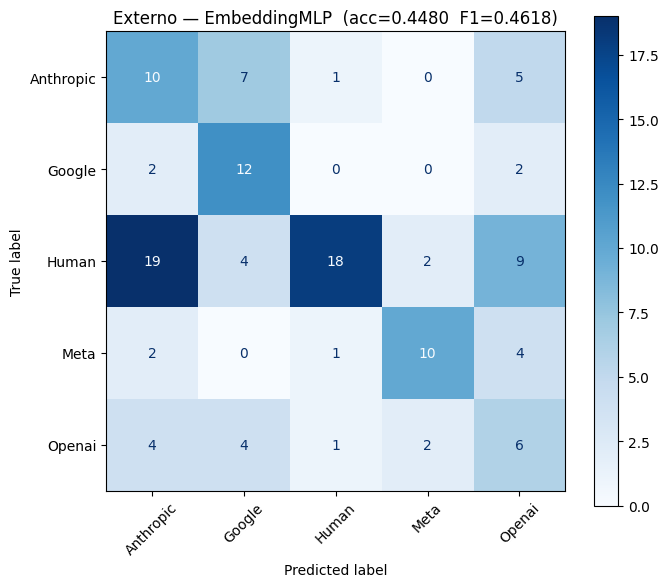

              precision    recall  f1-score   support

   Anthropic     0.2703    0.4348    0.3333        23
      Google     0.4444    0.7500    0.5581        16
       Human     0.8571    0.3462    0.4932        52
        Meta     0.7143    0.5882    0.6452        17
      Openai     0.2308    0.3529    0.2791        17

    accuracy                         0.4480       125
   macro avg     0.5034    0.4944    0.4618       125
weighted avg     0.5917    0.4480    0.4636       125



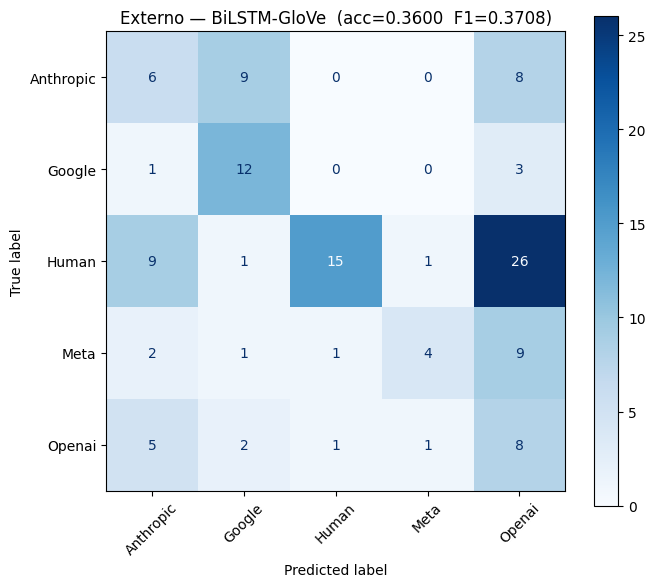

              precision    recall  f1-score   support

   Anthropic     0.2609    0.2609    0.2609        23
      Google     0.4800    0.7500    0.5854        16
       Human     0.8824    0.2885    0.4348        52
        Meta     0.6667    0.2353    0.3478        17
      Openai     0.1481    0.4706    0.2254        17

    accuracy                         0.3600       125
   macro avg     0.4876    0.4010    0.3708       125
weighted avg     0.5873    0.3600    0.3817       125



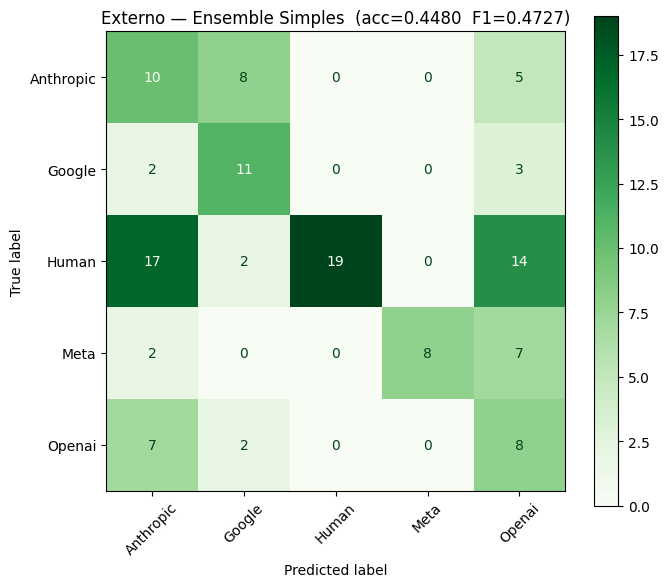

              precision    recall  f1-score   support

   Anthropic     0.2632    0.4348    0.3279        23
      Google     0.4783    0.6875    0.5641        16
       Human     1.0000    0.3654    0.5352        52
        Meta     1.0000    0.4706    0.6400        17
      Openai     0.2162    0.4706    0.2963        17

    accuracy                         0.4480       125
   macro avg     0.5915    0.4858    0.4727       125
weighted avg     0.6910    0.4480    0.4825       125



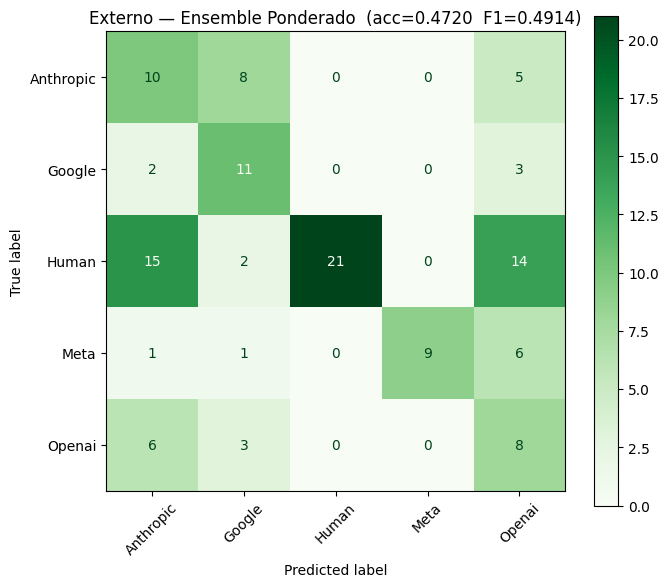

              precision    recall  f1-score   support

   Anthropic     0.2941    0.4348    0.3509        23
      Google     0.4400    0.6875    0.5366        16
       Human     1.0000    0.4038    0.5753        52
        Meta     1.0000    0.5294    0.6923        17
      Openai     0.2222    0.4706    0.3019        17

    accuracy                         0.4720       125
   macro avg     0.5913    0.5052    0.4914       125
weighted avg     0.6927    0.4720    0.5078       125



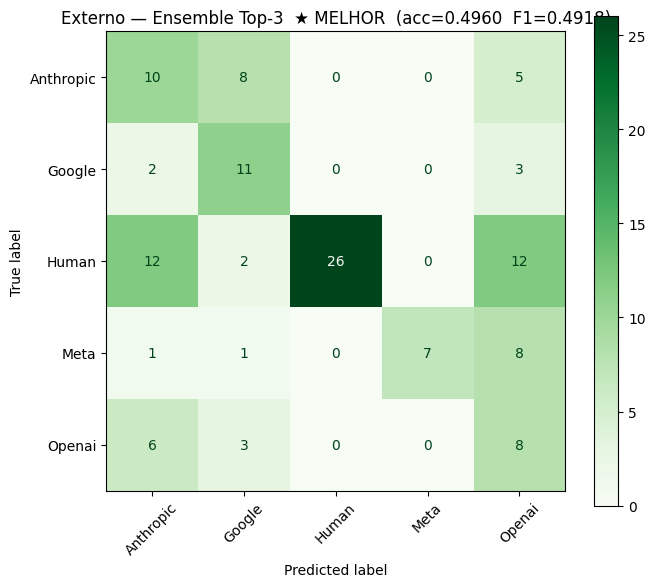

              precision    recall  f1-score   support

   Anthropic     0.3226    0.4348    0.3704        23
      Google     0.4400    0.6875    0.5366        16
       Human     1.0000    0.5000    0.6667        52
        Meta     1.0000    0.4118    0.5833        17
      Openai     0.2222    0.4706    0.3019        17

    accuracy                         0.4960       125
   macro avg     0.5970    0.5009    0.4918       125
weighted avg     0.6979    0.4960    0.5346       125



In [45]:
# ── Matrizes de confusão — dataset externo ────────────────────────────────────
lbls = [IDX_TO_CLASS[i] for i in range(N_CLASSES)]
best_ext_name = df_ext_res.iloc[0]['Modelo']

for name, (mdl, ldr) in ext_loader_map.items():
    acc_i  = ext_acc_map[name]
    f1_i   = sk_f1(np.array(ext_pred_map[name][1]),
                   np.array(ext_pred_map[name][0]), average='macro', zero_division=0)
    marker = '  ★ MELHOR' if name == best_ext_name else ''
    plot_confusion(mdl, ldr,
                   title=f'Externo — {name}{marker}  (acc={acc_i:.4f}  F1={f1_i:.4f})')

# Ensembles
ext_ens_configs = [
    ('Ensemble Simples',   list(ext_loader_map.keys()), None),
    ('Ensemble Ponderado', list(ext_loader_map.keys()), ext_weights),
    ('Ensemble Top-3',     top3_ext,                    None),
]
ext_ens_accs = {
    'Ensemble Simples':   acc_ext_simple,
    'Ensemble Ponderado': acc_ext_weighted,
    'Ensemble Top-3':     acc_ext_top3,
}
best_ext_ens = max(ext_ens_accs, key=ext_ens_accs.get)

for ens_label, names, w in ext_ens_configs:
    stack = np.stack([ext_proba_map[k] for k in names], axis=0)
    if w is not None:
        w_use = np.array([ext_acc_map[n] for n in names], dtype=np.float32)
        avg   = np.tensordot(w_use / w_use.sum(), stack, axes=([0], [0]))
    else:
        avg = stack.mean(axis=0)
    preds_e = avg.argmax(axis=1)
    acc_e   = (preds_e == targets_ext_arr).mean()
    f1_e    = sk_f1(targets_ext_arr, preds_e, average='macro', zero_division=0)
    short   = ens_label.split('(')[0].strip()
    marker  = '  ★ MELHOR' if short == best_ext_ens else ''
    cm = confusion_matrix(targets_ext_arr, preds_e)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=lbls).plot(
        ax=ax, xticks_rotation=45, cmap='Greens', values_format='d')
    ax.set_title(f'Externo — {ens_label}{marker}  (acc={acc_e:.4f}  F1={f1_e:.4f})')
    plt.tight_layout(); plt.show()
    print(classification_report(targets_ext_arr, preds_e, target_names=lbls, digits=4))

In [48]:
torch.save(gru_model.state_dict(), 'gru_model.pth')